<a href="https://colab.research.google.com/github/leorasdsouza/lulc-forest-change-detection/blob/main/Legend_2017_2025_compare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

FOREST COVER CHANGE ANALYSIS: 2017 vs 2025
Standalone Comparison Notebook

📊 LOADING 2017 RESULTS...
✓ Loaded 2017 results from pickle file
  2017 Forest: 94.1% (4489.21 km²)

📊 LOADING 2025 RESULTS...
2025 nodata value: 255.0
Converted 76411 pixels from 255.0 to 0
2025 unique values after cleaning: [0 1 2]
✓ Loaded 2025 classification map
  2025 Forest: 88.2% (4369.23 km²)

STARTING COMPARISON ANALYSIS

📈 PERFORMING COMPARISON ANALYSIS...

📊 PIXEL COUNTS:
  2017 valid pixels: 119,245
  2025 valid pixels: 123,880
  Common area pixels: 119,245

📊 CHANGE MATRIX (2017 → 2025):
Rows: 2017, Columns: 2025
0=Background, 1=Forest, 2=Non-forest
[[ 81046      0      0]
 [     0 103881   8420]
 [     0   2029   4915]]

🌳 FOREST CHANGE IN COMMON AREA:
  2017 Forest: 112,301 pixels (94.2%)
  2025 Forest: 105,910 pixels (88.8%)
  Change: -6,391 pixels (-5.4%)

  Area chan

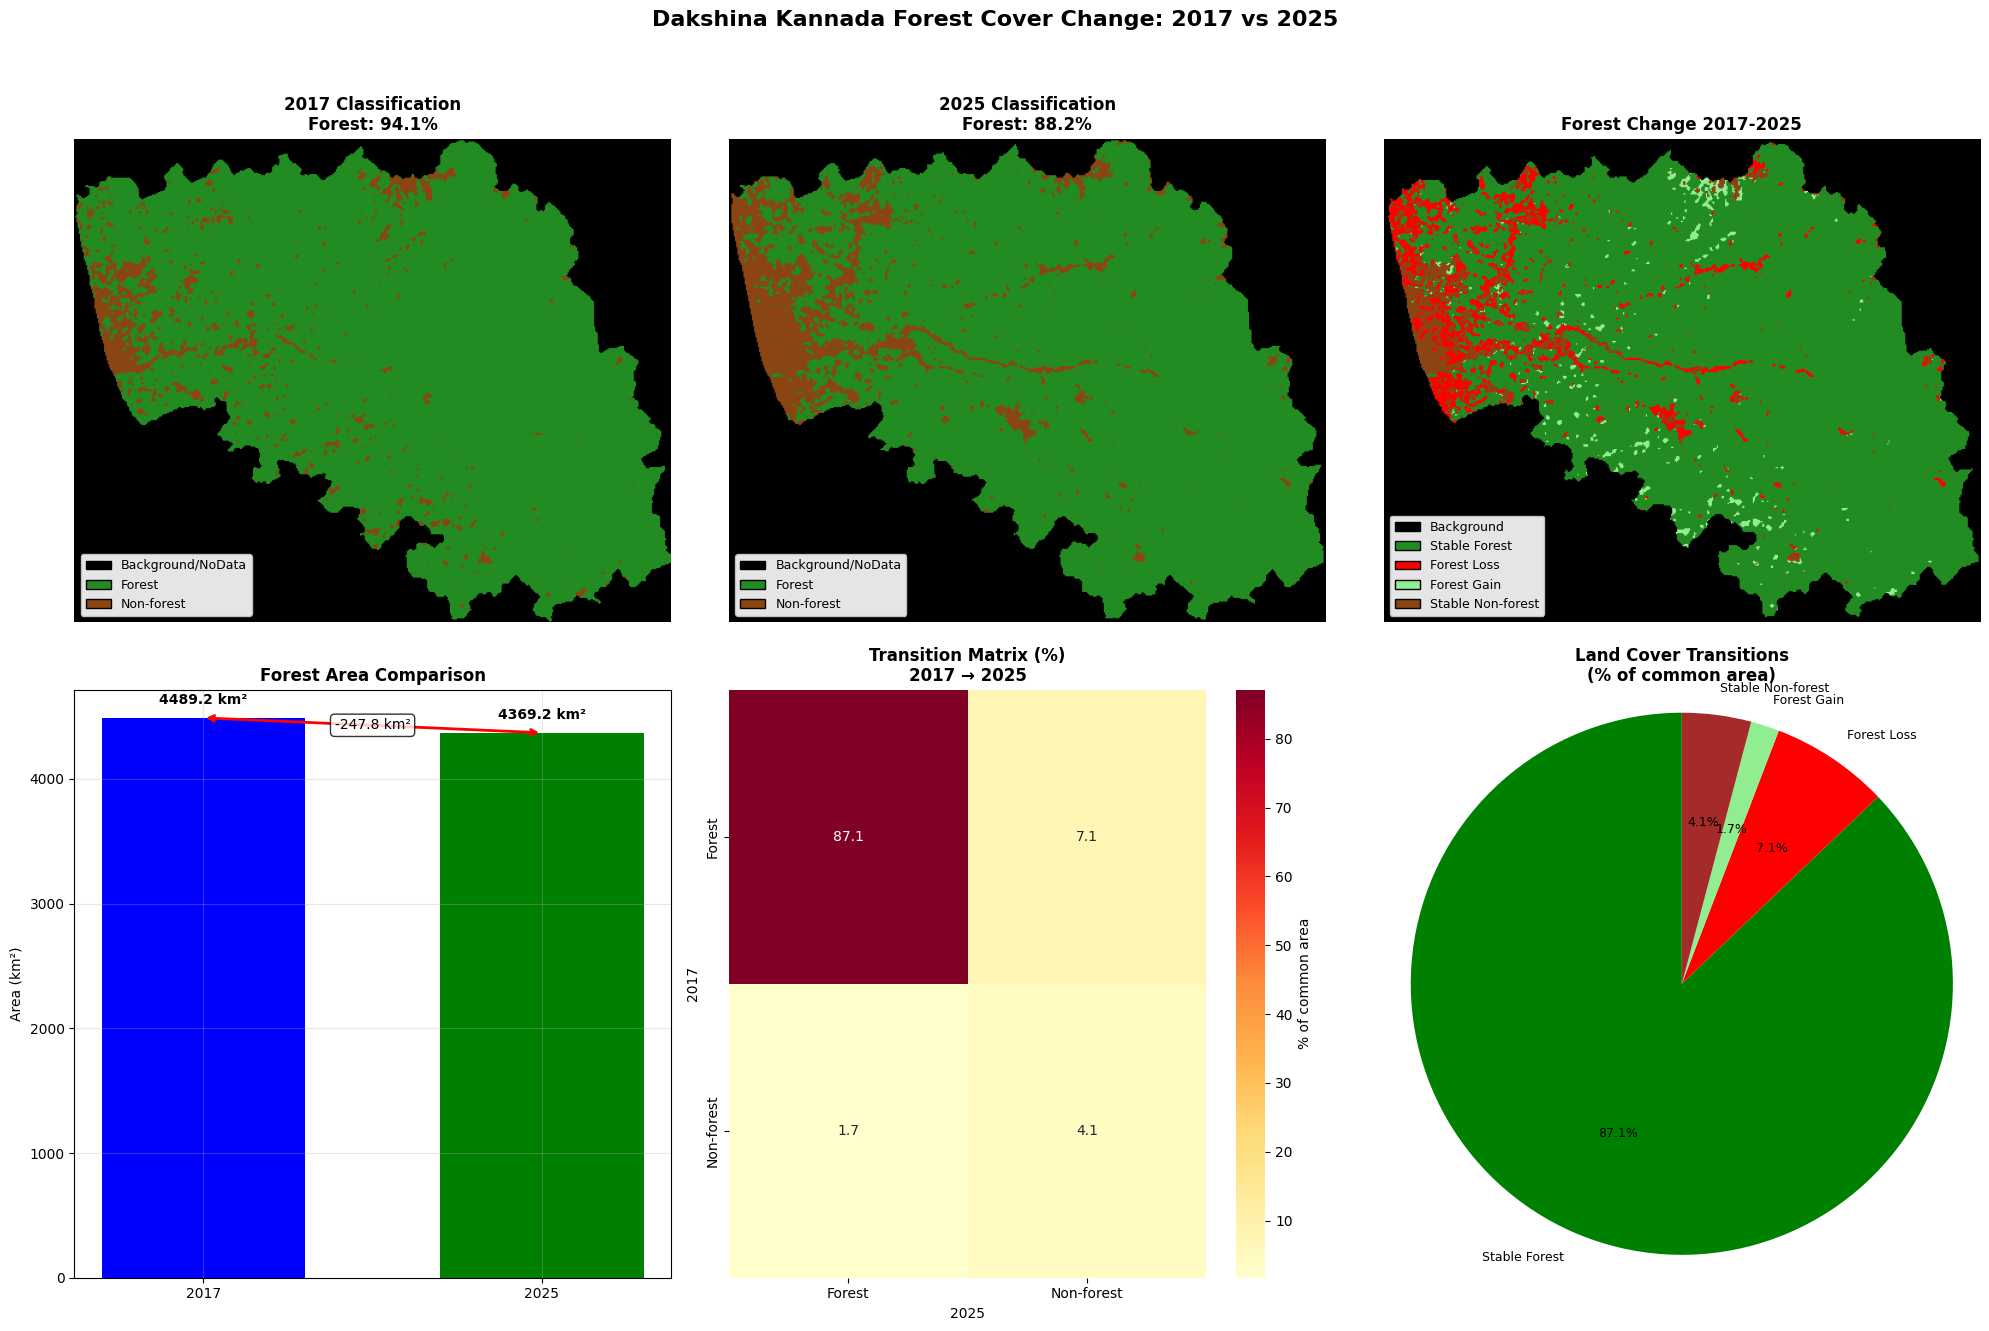

✓ Visualization saved: /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_2017_2025_Forest_Change_Comparison.png

💾 SAVING COMPARISON RESULTS...
✓ Change map saved: /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_Forest_Change_2017_2025.tif
✓ Comparison statistics saved: /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_2017_2025_Comparison_Statistics.csv
✓ Report generated: /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_TimeSeries_Comparison_Report.txt

COMPARISON ANALYSIS COMPLETE

📊 KEY FINDINGS:
  • 2017 Forest Cover: 94.1%
  • 2025 Forest Cover: 88.2%
  • Net Change (2017-2025): -5.4%
  • Annual Rate: -0.67% per year

📂 OUTPUT FILES:
  • /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_2017_2025_Forest_Change_Comparison.png
  • /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_Forest_Change_2017_2025.tif
  • /content/drive/MyDrive/Dakshina_Kannada_Comparison/DK_2017_2025_Comparison_Statistics.csv
  • /content/drive/MyDrive/Dakshina_Kannada_Comparison/D

In [ ]:
# ====================================================
# FOREST COVER CHANGE ANALYSIS: 2017 vs 2025
# Standalone Comparison Notebook
# ====================================================

# ----------------- Install & imports -----------------
!pip install -q rasterio scikit-learn matplotlib pandas seaborn

import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib.patches import Patch
from scipy.ndimage import zoom
import pickle

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ====================================================
# SETUP PATHS
# ====================================================

# Define paths (adjust as needed)
OUTPUT_DIR_2017 = "/content/drive/MyDrive/Dakshina_Kannada_2017"
OUTPUT_DIR_2025 = "/content/drive/MyDrive/clippeddk/leora"  # Your 2025 output
OUTPUT_COMPARISON = "/content/drive/MyDrive/Dakshina_Kannada_Comparison"

os.makedirs(OUTPUT_COMPARISON, exist_ok=True)

print("\n" + "="*70)
print("FOREST COVER CHANGE ANALYSIS: 2017 vs 2025")
print("Standalone Comparison Notebook")
print("="*70)

# ====================================================
# LOAD 2017 RESULTS
# ====================================================

print("\n📊 LOADING 2017 RESULTS...")

# Initialize variables
binary_2017 = None
mask_2017 = None
forest_percent_2017 = 0
forest_area_2017 = 0
forest_pixels_2017 = 0
total_pixels_2017 = 0
pixel_area_km2_2017 = 0

# Try to load from pickle file (created in Part 1)
results_2017_file = os.path.join(OUTPUT_DIR_2017, "results_2017.pkl")

if os.path.exists(results_2017_file):
    with open(results_2017_file, 'rb') as f:
        results_2017 = pickle.load(f)
    print("✓ Loaded 2017 results from pickle file")

    # Extract key data
    binary_2017 = results_2017['binary_map']
    forest_percent_2017 = results_2017['forest_percentage']
    forest_area_2017 = results_2017['forest_area_km2']
    forest_pixels_2017 = results_2017['forest_pixels']
    total_pixels_2017 = results_2017['total_pixels']
    pixel_area_km2_2017 = results_2017['pixel_area_km2']
    mask_2017 = results_2017['display_mask']
    print(f"  2017 Forest: {forest_percent_2017:.1f}% ({forest_area_2017:.2f} km²)")

elif os.path.exists(os.path.join(OUTPUT_DIR_2017, "DK_2017_Forest_Metrics.csv")):
    # Load from CSV and TIFF files if pickle doesn't exist
    print("✓ Loading 2017 results from CSV and TIFF files")

    # Load metrics
    metrics_2017_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_Forest_Metrics.csv")
    metrics_2017 = pd.read_csv(metrics_2017_file)

    forest_percent_2017 = metrics_2017['Forest_Percentage'].iloc[0]
    forest_area_2017 = metrics_2017['Forest_Area_km2'].iloc[0]
    forest_pixels_2017 = metrics_2017['Forest_Pixels'].iloc[0]
    total_pixels_2017 = metrics_2017['Total_Pixels'].iloc[0]
    pixel_area_km2_2017 = metrics_2017['Pixel_Area_km2'].iloc[0]

    # Load classification map
    binary_2017_file = os.path.join(OUTPUT_DIR_2017, "DK_LULC_2017_Autoencoder_Kmeans.tif")
    with rasterio.open(binary_2017_file) as src:
        binary_2017 = src.read(1)
        transform_2017 = src.transform
        crs_2017 = src.crs
        nodata_2017 = src.nodata

    # Create mask (pixels > 0 are valid)
    mask_2017 = binary_2017 > 0
    mask_2017 = mask_2017 & (binary_2017 != nodata_2017)

    print(f"  2017 Forest: {forest_percent_2017:.1f}% ({forest_area_2017:.2f} km²)")

else:
    print("❌ ERROR: No 2017 results found!")
    print(f"   Check if directory exists: {OUTPUT_DIR_2017}")
    print(f"   Expected files:")
    print(f"     - {results_2017_file}")
    print(f"     - DK_2017_Forest_Metrics.csv")
    print(f"     - DK_LULC_2017_Autoencoder_Kmeans.tif")
    raise FileNotFoundError("2017 results not found")

# ====================================================
# LOAD 2025 RESULTS
# ====================================================

print("\n📊 LOADING 2025 RESULTS...")

# Initialize variables
binary_2025 = None
forest_percent_2025 = 0
forest_area_2025 = 0
forest_pixels_2025 = 0
total_pixels_2025 = 0

# Try to find 2025 files
binary_2025_file = os.path.join(OUTPUT_DIR_2025, "LULC_Autoencoder_Kmeans_DW.tif")

if os.path.exists(binary_2025_file):
    with rasterio.open(binary_2025_file) as src:
        binary_2025 = src.read(1)
        transform_2025 = src.transform
        crs_2025 = src.crs
        nodata_2025 = src.nodata  # This is 255

        # FIX: Convert NoData (255) to 0 for proper visualization
        print(f"2025 nodata value: {nodata_2025}")
        if nodata_2025 is not None:
            # Create a copy and convert 255 to 0
            binary_2025_clean = binary_2025.copy()
            binary_2025_clean[binary_2025 == nodata_2025] = 0
            binary_2025 = binary_2025_clean
            print(f"Converted {np.sum(binary_2025 == 0)} pixels from {nodata_2025} to 0")

        print(f"2025 unique values after cleaning: {np.unique(binary_2025)}")

    print("✓ Loaded 2025 classification map")

    # Calculate forest pixels from binary map
    # After cleaning, nodata (255) is now 0, so background is 0
    mask_2025 = binary_2025 > 0  # Valid pixels are > 0
    forest_pixels_2025 = np.sum(binary_2025 == 1)
    total_pixels_2025 = np.sum(mask_2025)

    # Try to load metrics
    metrics_2025_file = os.path.join(OUTPUT_DIR_2025, "autoencoder_kmeans_dynamic_world_metrics.csv")

    if os.path.exists(metrics_2025_file):
        metrics_2025 = pd.read_csv(metrics_2025_file)

        # Check column names (they might vary)
        if 'Forest_Area_km2' in metrics_2025.columns:
            forest_area_2025 = metrics_2025['Forest_Area_km2'].iloc[0]
        elif 'Forest_Area_km2_Total' in metrics_2025.columns:
            forest_area_2025 = metrics_2025['Forest_Area_km2_Total'].iloc[0]
        else:
            # Calculate from pixels
            forest_area_2025 = forest_pixels_2025 * pixel_area_km2_2017

        if 'Forest_Percentage' in metrics_2025.columns:
            forest_percent_2025 = metrics_2025['Forest_Percentage'].iloc[0]
        elif 'Forest_Percentage_Total' in metrics_2025.columns:
            forest_percent_2025 = metrics_2025['Forest_Percentage_Total'].iloc[0]
        else:
            # Calculate from pixels
            forest_percent_2025 = (forest_pixels_2025 / total_pixels_2025 * 100) if total_pixels_2025 > 0 else 0

        print(f"  2025 Forest: {forest_percent_2025:.1f}% ({forest_area_2025:.2f} km²)")

    else:
        # Calculate metrics from binary map
        print("⚠️ 2025 metrics file not found, calculating from binary map...")
        forest_percent_2025 = (forest_pixels_2025 / total_pixels_2025 * 100) if total_pixels_2025 > 0 else 0
        forest_area_2025 = forest_pixels_2025 * pixel_area_km2_2017
        print(f"  2025 Forest: {forest_percent_2025:.1f}% ({forest_area_2025:.2f} km²)")

else:
    # Try alternative file names
    alt_files = [
        "LULC_Autoencoder_Kmeans.tif",
        "DK_2025_LULC.tif",
        "classification_2025.tif"
    ]

    binary_2025 = None
    for alt_file in alt_files:
        alt_path = os.path.join(OUTPUT_DIR_2025, alt_file)
        if os.path.exists(alt_path):
            with rasterio.open(alt_path) as src:
                binary_2025 = src.read(1)
                nodata_2025 = src.nodata

                # Apply the same fix for nodata
                if nodata_2025 is not None:
                    binary_2025_clean = binary_2025.copy()
                    binary_2025_clean[binary_2025 == nodata_2025] = 0
                    binary_2025 = binary_2025_clean

            print(f"✓ Loaded 2025 classification map from: {alt_file}")
            break

    if binary_2025 is None:
        print("❌ ERROR: No 2025 classification map found!")
        print(f"   Check directory: {OUTPUT_DIR_2025}")
        print(f"   Expected files:")
        print(f"     - LULC_Autoencoder_Kmeans_DW.tif")
        print(f"     - Or other classification TIFF files")
        raise FileNotFoundError("2025 classification map not found")

    # Calculate metrics
    mask_2025 = binary_2025 > 0
    forest_pixels_2025 = np.sum(binary_2025 == 1)
    total_pixels_2025 = np.sum(mask_2025)
    forest_percent_2025 = (forest_pixels_2025 / total_pixels_2025 * 100) if total_pixels_2025 > 0 else 0
    forest_area_2025 = forest_pixels_2025 * pixel_area_km2_2017
    print(f"  2025 Forest: {forest_percent_2025:.1f}% ({forest_area_2025:.2f} km²)")

# ====================================================
# COMPARISON ANALYSIS FUNCTION
# ====================================================

def compare_2017_2025(binary_2017, binary_2025, mask_2017,
                      forest_percent_2017, forest_area_2017, forest_pixels_2017,
                      forest_percent_2025, forest_area_2025, forest_pixels_2025,
                      pixel_area_km2, output_dir):
    """Compare 2017 and 2025 forest cover results"""

    print("\n📈 PERFORMING COMPARISON ANALYSIS...")

    # Ensure same shape (resample if necessary)
    if binary_2017.shape != binary_2025.shape:
        print(f"⚠️ Shape mismatch: 2017={binary_2017.shape}, 2025={binary_2025.shape}")

        # Determine which one to resample (resample the smaller to match the larger)
        if binary_2017.shape[0] * binary_2017.shape[1] > binary_2025.shape[0] * binary_2025.shape[1]:
            print("Resampling 2025 to match 2017...")
            scale_y = binary_2017.shape[0] / binary_2025.shape[0]
            scale_x = binary_2017.shape[1] / binary_2025.shape[1]
            binary_2025_resampled = zoom(binary_2025, (scale_y, scale_x), order=0)
            binary_2025_resampled = binary_2025_resampled[:binary_2017.shape[0], :binary_2017.shape[1]]
            binary_2025 = binary_2025_resampled
        else:
            print("Resampling 2017 to match 2025...")
            scale_y = binary_2025.shape[0] / binary_2017.shape[0]
            scale_x = binary_2025.shape[1] / binary_2017.shape[1]
            binary_2017_resampled = zoom(binary_2017, (scale_y, scale_x), order=0)
            binary_2017_resampled = binary_2017_resampled[:binary_2025.shape[0], :binary_2025.shape[1]]
            binary_2017 = binary_2017_resampled
            mask_2017 = zoom(mask_2017.astype(float), (scale_y, scale_x), order=0)
            mask_2017 = mask_2017_resampled[:binary_2025.shape[0], :binary_2025.shape[1]] > 0.5

    # Create masks for both years
    mask_2025 = binary_2025 > 0

    # Create common mask (valid in both years)
    common_mask = mask_2017 & mask_2025

    print(f"\n📊 PIXEL COUNTS:")
    print(f"  2017 valid pixels: {np.sum(mask_2017):,}")
    print(f"  2025 valid pixels: {np.sum(mask_2025):,}")
    print(f"  Common area pixels: {np.sum(common_mask):,}")

    # Calculate change matrix
    print("\n📊 CHANGE MATRIX (2017 → 2025):")

    # For common area only
    binary_2017_common = binary_2017.copy()
    binary_2025_common = binary_2025.copy()
    binary_2017_common[~common_mask] = 0
    binary_2025_common[~common_mask] = 0

    change_matrix = np.zeros((3, 3), dtype=int)  # 0=Background, 1=Forest, 2=Non-forest

    for i in range(3):
        for j in range(3):
            change_matrix[i, j] = np.sum((binary_2017_common == i) & (binary_2025_common == j))

    print("Rows: 2017, Columns: 2025")
    print("0=Background, 1=Forest, 2=Non-forest")
    print(change_matrix)

    # Extract change statistics
    stable_forest = change_matrix[1, 1]
    forest_loss = change_matrix[1, 2]    # Forest → Non-forest
    forest_gain = change_matrix[2, 1]    # Non-forest → Forest
    stable_nonforest = change_matrix[2, 2]

    total_common = np.sum(common_mask)

    # Calculate percentages
    if total_common > 0:
        forest_2017_common = stable_forest + forest_loss
        forest_2025_common = stable_forest + forest_gain

        forest_percent_2017_common = (forest_2017_common / total_common) * 100
        forest_percent_2025_common = (forest_2025_common / total_common) * 100

        forest_change_pixels = forest_2025_common - forest_2017_common
        forest_change_percent = forest_percent_2025_common - forest_percent_2017_common

        # Area calculations
        forest_area_2017_common = forest_2017_common * pixel_area_km2
        forest_area_2025_common = forest_2025_common * pixel_area_km2
        area_change_km2 = forest_area_2025_common - forest_area_2017_common

        print(f"\n🌳 FOREST CHANGE IN COMMON AREA:")
        print(f"  2017 Forest: {forest_2017_common:,} pixels ({forest_percent_2017_common:.1f}%)")
        print(f"  2025 Forest: {forest_2025_common:,} pixels ({forest_percent_2025_common:.1f}%)")
        print(f"  Change: {forest_change_pixels:+,} pixels ({forest_change_percent:+.1f}%)")
        print(f"\n  Area change: {area_change_km2:+.2f} km²")
        print(f"  (2017: {forest_area_2017_common:.2f} km² → 2025: {forest_area_2025_common:.2f} km²)")

        print(f"\n📊 CHANGE CATEGORIES:")
        print(f"  Stable forest: {stable_forest:,} pixels ({stable_forest/total_common*100:.1f}%)")
        print(f"  Forest loss: {forest_loss:,} pixels ({forest_loss/total_common*100:.1f}%)")
        print(f"  Forest gain: {forest_gain:,} pixels ({forest_gain/total_common*100:.1f}%)")
        print(f"  Stable non-forest: {stable_nonforest:,} pixels ({stable_nonforest/total_common*100:.1f}%)")

        # Net change rate per year
        years_between = 2025 - 2017
        annual_change_rate = forest_change_percent / years_between
        print(f"\n📅 ANNUAL CHANGE RATE (2017-2025):")
        print(f"  {annual_change_rate:+.2f}% per year")
    else:
        print("⚠️ No common area for comparison!")
        return None

    # ====================================================
    # CREATE CHANGE MAP
    # ====================================================
    print("\n🗺️ CREATING CHANGE MAP...")

    # 0 = Background/NoData
    # 1 = Stable forest
    # 2 = Forest loss (2017 forest → 2025 non-forest)
    # 3 = Forest gain (2017 non-forest → 2025 forest)
    # 4 = Stable non-forest

    change_map = np.zeros_like(binary_2017, dtype=np.uint8)

    change_map[(binary_2017 == 1) & (binary_2025 == 1) & common_mask] = 1  # Stable forest
    change_map[(binary_2017 == 1) & (binary_2025 == 2) & common_mask] = 2  # Forest loss
    change_map[(binary_2017 == 2) & (binary_2025 == 1) & common_mask] = 3  # Forest gain
    change_map[(binary_2017 == 2) & (binary_2025 == 2) & common_mask] = 4  # Stable non-forest

    # ====================================================
    # VISUALIZATION
    # ====================================================

    print("\n🎨 CREATING COMPARISON VISUALIZATIONS...")

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('Dakshina Kannada Forest Cover Change: 2017 vs 2025',
                 fontsize=16, fontweight='bold', y=1.02)

    # 1. 2017 Classification with legend (bottom left corner)
    cmap_class = ListedColormap(['#000000', '#228B22', '#8B4513'])
    im1 = axes[0,0].imshow(binary_2017, cmap=cmap_class, vmin=0, vmax=2)
    axes[0,0].set_title(f'2017 Classification\nForest: {forest_percent_2017:.1f}%', fontweight='bold')
    axes[0,0].axis('off')

    # Add legend for 2017 classification (bottom left corner)
    legend_elements_2017 = [
        Patch(facecolor='#000000', edgecolor='black', label='Background/NoData'),
        Patch(facecolor='#228B22', edgecolor='black', label='Forest'),
        Patch(facecolor='#8B4513', edgecolor='black', label='Non-forest')
    ]
    axes[0,0].legend(handles=legend_elements_2017, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 2. 2025 Classification with legend (bottom left corner)
    im2 = axes[0,1].imshow(binary_2025, cmap=cmap_class, vmin=0, vmax=2)
    axes[0,1].set_title(f'2025 Classification\nForest: {forest_percent_2025:.1f}%', fontweight='bold')
    axes[0,1].axis('off')

    # Add legend for 2025 classification (bottom left corner)
    axes[0,1].legend(handles=legend_elements_2017, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 3. Change Map with legend (bottom left corner)
    change_cmap = ListedColormap(['#000000', '#228B22', '#FF0000', '#90EE90', '#8B4513'])
    im3 = axes[0,2].imshow(change_map, cmap=change_cmap, vmin=0, vmax=4)
    axes[0,2].set_title('Forest Change 2017-2025', fontweight='bold')
    axes[0,2].axis('off')

    # Add legend for change map (bottom left corner)
    legend_elements_change = [
        Patch(facecolor='#000000', edgecolor='black', label='Background'),
        Patch(facecolor='#228B22', edgecolor='black', label='Stable Forest'),
        Patch(facecolor='#FF0000', edgecolor='black', label='Forest Loss'),
        Patch(facecolor='#90EE90', edgecolor='black', label='Forest Gain'),
        Patch(facecolor='#8B4513', edgecolor='black', label='Stable Non-forest')
    ]
    axes[0,2].legend(handles=legend_elements_change, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 4. Forest Area Comparison Bar Chart
    years = ['2017', '2025']
    forest_areas = [forest_area_2017, forest_area_2025]

    bars = axes[1,0].bar(years, forest_areas, color=['blue', 'green'], width=0.6)
    axes[1,0].set_title('Forest Area Comparison', fontweight='bold')
    axes[1,0].set_ylabel('Area (km²)')
    axes[1,0].grid(True, alpha=0.3)

    # Add value labels
    for bar, area in zip(bars, forest_areas):
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + max(forest_areas)*0.02,
                      f'{area:.1f} km²', ha='center', va='bottom', fontweight='bold')

    # Add change arrow
    change_text = f"{area_change_km2:+.1f} km²"
    arrow_color = 'green' if area_change_km2 >= 0 else 'red'
    axes[1,0].annotate('', xy=(1, forest_area_2025), xytext=(0, forest_area_2017),
                      arrowprops=dict(arrowstyle='<->', color=arrow_color, lw=2))
    axes[1,0].text(0.5, (forest_area_2017 + forest_area_2025)/2,
                  change_text, ha='center', va='center',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # 5. Transition Matrix Heatmap
    change_matrix_norm = change_matrix[1:, 1:] / np.sum(change_matrix[1:, 1:]) * 100

    sns.heatmap(change_matrix_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=['Forest', 'Non-forest'],
                yticklabels=['Forest', 'Non-forest'],
                cbar_kws={'label': '% of common area'},
                ax=axes[1,1])
    axes[1,1].set_title('Transition Matrix (%)\n2017 → 2025', fontweight='bold')
    axes[1,1].set_xlabel('2025')
    axes[1,1].set_ylabel('2017')

    # 6. Change Composition Pie Chart
    labels = ['Stable Forest', 'Forest Loss', 'Forest Gain', 'Stable Non-forest']
    sizes = [stable_forest, forest_loss, forest_gain, stable_nonforest]
    colors = ['green', 'red', 'lightgreen', 'brown']

    # Filter out zero categories
    non_zero_indices = [i for i, size in enumerate(sizes) if size > 0]
    if non_zero_indices:
        labels_filtered = [labels[i] for i in non_zero_indices]
        sizes_filtered = [sizes[i] for i in non_zero_indices]
        colors_filtered = [colors[i] for i in non_zero_indices]

        axes[1,2].pie(sizes_filtered, labels=labels_filtered, colors=colors_filtered,
                     autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
        axes[1,2].axis('equal')
        axes[1,2].set_title('Land Cover Transitions\n(% of common area)', fontweight='bold')
    else:
        axes[1,2].text(0.5, 0.5, 'No transitions\nin common area',
                      ha='center', va='center', transform=axes[1,2].transAxes)
        axes[1,2].axis('off')

    plt.tight_layout()

    # Save visualization
    vis_path = os.path.join(output_dir, "DK_2017_2025_Forest_Change_Comparison.png")
    plt.savefig(vis_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Visualization saved: {vis_path}")

    # ====================================================
    # SAVE COMPARISON RESULTS
    # ====================================================
    print("\n💾 SAVING COMPARISON RESULTS...")

    # Save change map
    change_map_file = os.path.join(output_dir, "DK_Forest_Change_2017_2025.tif")

    # Try to get metadata from 2017 or 2025 file
    meta = {}
    try:
        # Try 2017 file first
        tif_2017_file = os.path.join(OUTPUT_DIR_2017, "DK_LULC_2017_Autoencoder_Kmeans.tif")
        if os.path.exists(tif_2017_file):
            with rasterio.open(tif_2017_file) as src:
                meta = src.meta.copy()
        else:
            # Try 2025 file
            with rasterio.open(binary_2025_file) as src:
                meta = src.meta.copy()
    except:
        pass

    if not meta:
        # Create basic metadata
        meta = {
            "driver": "GTiff",
            "height": change_map.shape[0],
            "width": change_map.shape[1],
            "count": 1,
            "dtype": "uint8",
            "nodata": 0,
            "compress": "LZW"
        }

    meta.update({
        "height": change_map.shape[0],
        "width": change_map.shape[1],
        "count": 1,
        "dtype": "uint8",
        "nodata": 0
    })

    with rasterio.open(change_map_file, "w", **meta) as dst:
        dst.write(change_map, 1)
        # Add colormap
        try:
            dst.write_colormap(1, {
                0: (0, 0, 0),       # Black - Background
                1: (34, 139, 34),   # Green - Stable forest
                2: (255, 0, 0),     # Red - Forest loss
                3: (144, 238, 144), # Light green - Forest gain
                4: (139, 69, 19)    # Brown - Stable non-forest
            })
        except:
            pass

    print(f"✓ Change map saved: {change_map_file}")

    # Save comparison statistics
    comparison_stats = {
        'Year': ['2017', '2025', 'Change'],
        'Forest_Pixels_Total': [
            forest_pixels_2017,
            forest_pixels_2025,
            forest_pixels_2025 - forest_pixels_2017
        ],
        'Forest_Percentage_Total': [
            forest_percent_2017,
            forest_percent_2025,
            forest_percent_2025 - forest_percent_2017
        ],
        'Forest_Area_km2_Total': [
            forest_area_2017,
            forest_area_2025,
            forest_area_2025 - forest_area_2017
        ],
        'Common_Area_Pixels': [total_common, total_common, 0],
        'Forest_Pixels_Common': [forest_2017_common, forest_2025_common, forest_change_pixels],
        'Forest_Percentage_Common': [forest_percent_2017_common, forest_percent_2025_common, forest_change_percent],
        'Forest_Area_km2_Common': [forest_area_2017_common, forest_area_2025_common, area_change_km2],
        'Stable_Forest_Pixels': [stable_forest, stable_forest, 0],
        'Forest_Loss_Pixels': [forest_loss, forest_loss, 0],
        'Forest_Gain_Pixels': [forest_gain, forest_gain, 0],
        'Stable_NonForest_Pixels': [stable_nonforest, stable_nonforest, 0],
        'Pixel_Area_km2': [pixel_area_km2, pixel_area_km2, 0]
    }

    comparison_df = pd.DataFrame(comparison_stats)
    stats_path = os.path.join(output_dir, "DK_2017_2025_Comparison_Statistics.csv")
    comparison_df.to_csv(stats_path, index=False)
    print(f"✓ Comparison statistics saved: {stats_path}")

    # Generate comprehensive report
    report_path = os.path.join(output_dir, "DK_TimeSeries_Comparison_Report.txt")
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("DAKSHINA KANNADA FOREST COVER CHANGE ANALYSIS REPORT\n")
        f.write("2017 vs 2025 Time Series Comparison\n")
        f.write("="*80 + "\n\n")

        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*40 + "\n")
        f.write(f"Forest cover in 2017: {forest_percent_2017:.1f}%\n")
        f.write(f"Forest cover in 2025: {forest_percent_2025:.1f}%\n")
        f.write(f"Net change (2017-2025): {forest_change_percent:+.1f}%\n")
        f.write(f"Annual change rate: {annual_change_rate:+.2f}% per year\n\n")

        f.write(f"Forest area in 2017: {forest_area_2017:.2f} km²\n")
        f.write(f"Forest area in 2025: {forest_area_2025:.2f} km²\n")
        f.write(f"Area change: {area_change_km2:+.2f} km²\n\n")

        f.write("CHANGE CATEGORIES (Common Area)\n")
        f.write("-"*40 + "\n")
        f.write(f"Stable forest: {stable_forest:,} pixels ({stable_forest/total_common*100:.1f}%)\n")
        f.write(f"Forest loss: {forest_loss:,} pixels ({forest_loss/total_common*100:.1f}%)\n")
        f.write(f"Forest gain: {forest_gain:,} pixels ({forest_gain/total_common*100:.1f}%)\n")
        f.write(f"Stable non-forest: {stable_nonforest:,} pixels ({stable_nonforest/total_common*100:.1f}%)\n\n")

        f.write("METHODOLOGY\n")
        f.write("-"*40 + "\n")
        f.write("2017 Data:\n")
        f.write("  • Source: Sentinel-2 TOA (Top of Atmosphere)\n")
        f.write("  • Period: January-February 2017\n")
        f.write("  • Processing: Autoencoder + K-means clustering\n")
        f.write("  • Classification: Forest (NDVI > 0.4) vs Non-forest\n")
        f.write("\n2025 Data:\n")
        f.write("  • Source: Sentinel-2 SR (Surface Reflectance)\n")
        f.write("  • Period: January-February 2025\n")
        f.write("  • Processing: Autoencoder + K-means clustering\n")
        f.write("  • Validation: Dynamic World reference data\n")
        f.write("\nComparison:\n")
        f.write("  • Pixel-by-pixel analysis in common area\n")
        f.write("  • Change matrix calculation\n")
        f.write("  • Area calculation using geographic projection\n")
        f.write(f"  • Pixel area: {pixel_area_km2:.6f} km²\n\n")

        f.write("DATA QUALITY NOTES\n")
        f.write("-"*40 + "\n")
        f.write("1. 2017 data is TOA, 2025 data is SR - reflectance differences exist\n")
        f.write("2. Different atmospheric correction methods\n")
        f.write("3. Same classification thresholds applied to both years\n")
        f.write("4. Common area analysis ensures fair comparison\n")
        f.write("5. Annual rate calculated over 8-year period (2017-2025)\n\n")

        f.write("INTERPRETATION GUIDANCE\n")
        f.write("-"*40 + "\n")
        f.write("• Positive change = Forest increase (regeneration, plantation)\n")
        f.write("• Negative change = Forest decrease (deforestation, degradation)\n")
        f.write("• Stable forest = No change in forest cover\n")
        f.write("• Forest gain = Afforestation/reforestation\n")
        f.write("• Forest loss = Deforestation/land use change\n")

    print(f"✓ Report generated: {report_path}")

    # Summary
    print("\n" + "="*70)
    print("COMPARISON ANALYSIS COMPLETE")
    print("="*70)
    print(f"\n📊 KEY FINDINGS:")
    print(f"  • 2017 Forest Cover: {forest_percent_2017:.1f}%")
    print(f"  • 2025 Forest Cover: {forest_percent_2025:.1f}%")
    print(f"  • Net Change (2017-2025): {forest_change_percent:+.1f}%")
    print(f"  • Annual Rate: {annual_change_rate:+.2f}% per year")

    print(f"\n📂 OUTPUT FILES:")
    print(f"  • {vis_path}")
    print(f"  • {change_map_file}")
    print(f"  • {stats_path}")
    print(f"  • {report_path}")

    return {
        'change_map': change_map,
        'comparison_df': comparison_df,
        'change_matrix': change_matrix,
        'forest_change_percent': forest_change_percent,
        'annual_change_rate': annual_change_rate
    }

# ====================================================
# RUN THE COMPARISON
# ====================================================

print("\n" + "="*70)
print("STARTING COMPARISON ANALYSIS")
print("="*70)

# Run comparison
comparison_results = compare_2017_2025(
    binary_2017=binary_2017,
    binary_2025=binary_2025,
    mask_2017=mask_2017,
    forest_percent_2017=forest_percent_2017,
    forest_area_2017=forest_area_2017,
    forest_pixels_2017=forest_pixels_2017,
    forest_percent_2025=forest_percent_2025,
    forest_area_2025=forest_area_2025,
    forest_pixels_2025=forest_pixels_2025,
    pixel_area_km2=pixel_area_km2_2017,
    output_dir=OUTPUT_COMPARISON
)

# ====================================================
# FINAL SUMMARY
# ====================================================

print("\n" + "="*70)
print("TIME SERIES ANALYSIS COMPLETE")
print("="*70)

print("\n📋 WHAT WAS ACCOMPLISHED:")
print("1. ✅ 2017 forest cover data loaded")
print("2. ✅ 2025 forest cover data loaded")
print("3. ✅ Comprehensive comparison analysis")
print("4. ✅ Change detection and transition matrix")
print("5. ✅ Area calculations and annual change rates")

print(f"\n📂 OUTPUT DIRECTORIES:")
print(f"   2017 Results: {OUTPUT_DIR_2017}")
print(f"   2025 Results: {OUTPUT_DIR_2025}")
print(f"   Comparison Results: {OUTPUT_COMPARISON}")

print("\n⚠️  IMPORTANT NOTES:")
print("   1. 2017: Sentinel-2 TOA (Top of Atmosphere)")
print("   2. 2025: Sentinel-2 SR (Surface Reflectance)")
print("   3. Different atmospheric correction methods")
print("   4. Same classification thresholds used for consistency")
print("   5. Results show relative change, not absolute accuracy")

print("\n🎉 ANALYSIS COMPLETED SUCCESSFULLY!")
print("   You now have comparable forest cover maps for 2017 and 2025")
print("   with detailed change analysis between the two years.")

# ====================================================
# OPTIONAL: SAVE COMPARISON RESULTS FOR FUTURE USE
# ====================================================

if comparison_results:
    # Save comparison results
    comparison_results_file = os.path.join(OUTPUT_COMPARISON, "comparison_results.pkl")
    with open(comparison_results_file, 'wb') as f:
        pickle.dump(comparison_results, f)
    print(f"\n✓ Comparison results saved: {comparison_results_file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

DEEP EMBEDDED CLUSTERING COMPARISON: 2017 vs 2025
Standalone Comparison Notebook

📊 LOADING 2017 DEC RESULTS...
✓ Loaded 2017 DEC results from pickle file
  2017 DEC Forest: 93.4% (4456.84 km²)

📊 LOADING 2025 DEC RESULTS...
2025 DEC nodata value: 255.0
Converted 76411 pixels from 255.0 to 0
2025 DEC unique values after cleaning: [0 1 2]
✓ Loaded 2025 DEC classification map from: LULC_Deep_Embedded_Clustering_DW_interior_improved_ae.tif
  2025 DEC Forest: 88.8% (4264.21 km²)

STARTING DEEP EMBEDDED CLUSTERING COMPARISON

📈 PERFORMING DEC COMPARISON ANALYSIS...

📊 PIXEL COUNTS:
  2017 valid pixels: 119,245
  2025 valid pixels: 123,880
  Common area pixels: 119,245

📊 CHANGE MATRIX (2017 → 2025):
Rows: 2017, Columns: 2025
0=Background, 1=Forest, 2=Non-forest
[[ 81046      0      0]
 [     0 104086   7406]
 [     0   2162   5591]]

🌳 FOREST CHANGE IN COMMON ARE

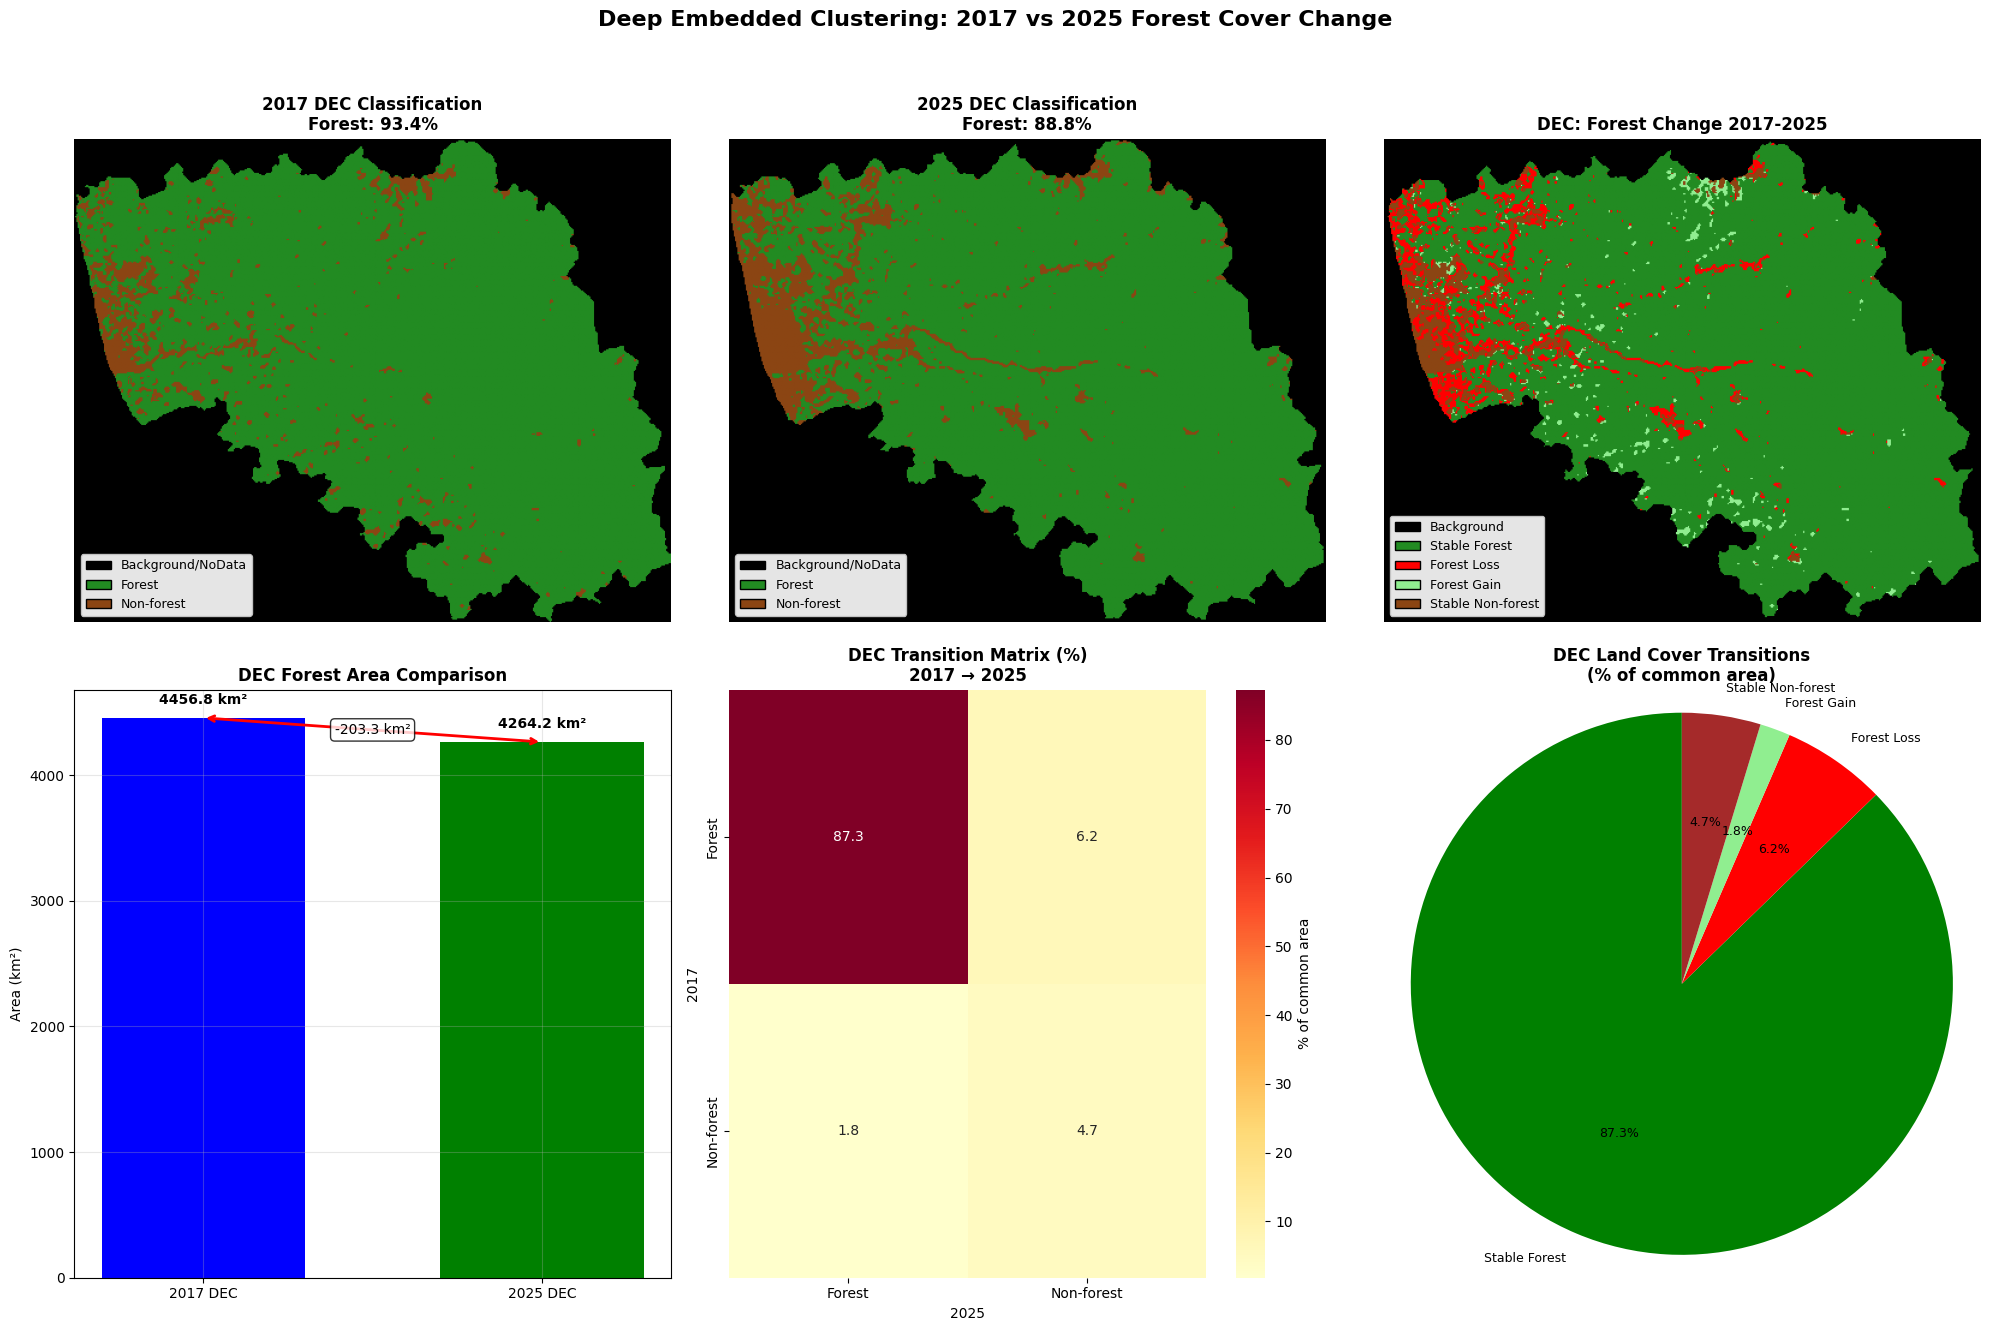

✓ DEC visualization saved: /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_2017_2025_DEC_Forest_Change_Comparison.png

💾 SAVING DEC COMPARISON RESULTS...
✓ DEC change map saved: /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_Forest_Change_2017_2025_DEC.tif


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


✓ DEC comparison statistics saved: /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_2017_2025_DEC_Comparison_Statistics.csv
✓ DEC report generated: /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_DEC_TimeSeries_Comparison_Report.txt

DEEP EMBEDDED CLUSTERING COMPARISON COMPLETE

📊 KEY FINDINGS:
  • 2017 Forest Cover (DEC): 93.4%
  • 2025 Forest Cover (DEC): 88.8%
  • Net Change (2017-2025): -4.4%
  • Annual Rate: -0.55% per year

📂 OUTPUT FILES:
  • /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_2017_2025_DEC_Forest_Change_Comparison.png
  • /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_Forest_Change_2017_2025_DEC.tif
  • /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_2017_2025_DEC_Comparison_Statistics.csv
  • /content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison/DK_DEC_TimeSeries_Comparison_Report.txt

DEEP EMBEDDED CLUSTERING ANALYSIS COMPLETE

📋 WHAT WAS ACCOMPLISHED:
1. ✅ 2017 DEC analysis completed
2. ✅ 2025 DEC results loaded

In [ ]:
# ====================================================
# DEEP EMBEDDED CLUSTERING COMPARISON: 2017 vs 2025
# Standalone Comparison Notebook
# ====================================================

# ----------------- Install & imports -----------------
!pip install -q rasterio scikit-learn matplotlib pandas seaborn

import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib.patches import Patch
from scipy.ndimage import zoom
import pickle

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ====================================================
# SETUP PATHS
# ====================================================

# Define paths (adjust as needed)
OUTPUT_DIR_2017_DEC = "/content/drive/MyDrive/Dakshina_Kannada_2017_DEC"
OUTPUT_DIR_2025_DEC = "/content/drive/MyDrive/clippeddk/leora"  # Your 2025 DEC output
OUTPUT_COMPARISON_DEC = "/content/drive/MyDrive/Dakshina_Kannada_DEC_Comparison"

os.makedirs(OUTPUT_COMPARISON_DEC, exist_ok=True)

print("\n" + "="*70)
print("DEEP EMBEDDED CLUSTERING COMPARISON: 2017 vs 2025")
print("Standalone Comparison Notebook")
print("="*70)

# ====================================================
# LOAD 2017 DEC RESULTS
# ====================================================

print("\n📊 LOADING 2017 DEC RESULTS...")

# Try to load from pickle file
results_2017_dec_file = os.path.join(OUTPUT_DIR_2017_DEC, "results_2017_dec.pkl")

if os.path.exists(results_2017_dec_file):
    with open(results_2017_dec_file, 'rb') as f:
        results_2017_dec = pickle.load(f)
    print("✓ Loaded 2017 DEC results from pickle file")

    # Extract data
    binary_2017_dec = results_2017_dec['binary_map']
    forest_percent_2017_dec = results_2017_dec['forest_percentage']
    forest_area_2017_dec = results_2017_dec['forest_area_km2']
    forest_pixels_2017_dec = results_2017_dec['forest_pixels']
    total_pixels_2017_dec = results_2017_dec['total_pixels']
    pixel_area_km2_2017 = results_2017_dec['pixel_area_km2']
    mask_2017_dec = results_2017_dec['display_mask']
    print(f"  2017 DEC Forest: {forest_percent_2017_dec:.1f}% ({forest_area_2017_dec:.2f} km²)")

elif os.path.exists(os.path.join(OUTPUT_DIR_2017_DEC, "DK_2017_DEC_Metrics.csv")):
    # Load from CSV and TIFF files if pickle doesn't exist
    print("✓ Loading 2017 DEC results from CSV and TIFF files")

    # Load metrics
    metrics_2017_dec_file = os.path.join(OUTPUT_DIR_2017_DEC, "DK_2017_DEC_Metrics.csv")
    metrics_2017_dec = pd.read_csv(metrics_2017_dec_file)

    forest_percent_2017_dec = metrics_2017_dec['Forest_Percentage'].iloc[0]
    forest_area_2017_dec = metrics_2017_dec['Forest_Area_km2'].iloc[0]
    forest_pixels_2017_dec = metrics_2017_dec['Forest_Pixels'].iloc[0]
    total_pixels_2017_dec = metrics_2017_dec['Total_Pixels'].iloc[0]
    pixel_area_km2_2017 = metrics_2017_dec['Pixel_Area_km2'].iloc[0]

    # Load classification map
    binary_2017_dec_file = os.path.join(OUTPUT_DIR_2017_DEC, "DK_LULC_2017_Deep_Embedded_Clustering.tif")
    with rasterio.open(binary_2017_dec_file) as src:
        binary_2017_dec = src.read(1)
        nodata_2017_dec = src.nodata

    # Create mask
    mask_2017_dec = binary_2017_dec > 0
    mask_2017_dec = mask_2017_dec & (binary_2017_dec != nodata_2017_dec)

    print(f"  2017 DEC Forest: {forest_percent_2017_dec:.1f}% ({forest_area_2017_dec:.2f} km²)")

else:
    print("❌ ERROR: No 2017 DEC results found!")
    print(f"   Check if directory exists: {OUTPUT_DIR_2017_DEC}")
    raise FileNotFoundError("2017 DEC results not found")

# ====================================================
# LOAD 2025 DEC RESULTS
# ====================================================

# ====================================================
# LOAD 2025 DEC RESULTS
# ====================================================

print("\n📊 LOADING 2025 DEC RESULTS...")

# Try to find 2025 DEC files
binary_2025_dec_files = [
    "LULC_Deep_Embedded_Clustering_DW_interior_improved_ae.tif",
    "LULC_Deep_Embedded_Clustering.tif",
    "DK_2025_DEC.tif"
]

binary_2025_dec = None
for dec_file in binary_2025_dec_files:
    dec_path = os.path.join(OUTPUT_DIR_2025_DEC, dec_file)
    if os.path.exists(dec_path):
        with rasterio.open(dec_path) as src:
            binary_2025_dec = src.read(1)
            nodata_2025_dec = src.nodata

            # FIX: Convert NoData (255) to 0 for proper visualization
            print(f"2025 DEC nodata value: {nodata_2025_dec}")
            if nodata_2025_dec is not None:
                # Create a copy and convert NoData values to 0
                binary_2025_dec_clean = binary_2025_dec.copy()
                binary_2025_dec_clean[binary_2025_dec == nodata_2025_dec] = 0
                binary_2025_dec = binary_2025_dec_clean
                print(f"Converted {np.sum(binary_2025_dec == 0)} pixels from {nodata_2025_dec} to 0")

            print(f"2025 DEC unique values after cleaning: {np.unique(binary_2025_dec)}")

        print(f"✓ Loaded 2025 DEC classification map from: {dec_file}")
        break

if binary_2025_dec is None:
    print("❌ ERROR: No 2025 DEC classification map found!")
    raise FileNotFoundError("2025 DEC classification map not found")

# Create mask for 2025 - after cleaning, background is 0
mask_2025_dec = binary_2025_dec > 0  # Valid pixels are > 0

# Calculate 2025 metrics
forest_pixels_2025_dec = np.sum(binary_2025_dec == 1)
total_pixels_2025_dec = np.sum(mask_2025_dec)
forest_percent_2025_dec = (forest_pixels_2025_dec / total_pixels_2025_dec * 100) if total_pixels_2025_dec > 0 else 0
forest_area_2025_dec = forest_pixels_2025_dec * pixel_area_km2_2017

print(f"  2025 DEC Forest: {forest_percent_2025_dec:.1f}% ({forest_area_2025_dec:.2f} km²)")

# ====================================================
# DEC COMPARISON ANALYSIS FUNCTION
# ====================================================

def compare_dec_2017_2025(binary_2017, binary_2025, mask_2017,
                         forest_percent_2017, forest_area_2017, forest_pixels_2017,
                         forest_percent_2025, forest_area_2025, forest_pixels_2025,
                         pixel_area_km2, output_dir):
    """Compare 2017 and 2025 Deep Embedded Clustering results"""

    print("\n📈 PERFORMING DEC COMPARISON ANALYSIS...")

    # Ensure same shape (resample if necessary)
    if binary_2017.shape != binary_2025.shape:
        print(f"⚠️ Shape mismatch: 2017={binary_2017.shape}, 2025={binary_2025.shape}")

        # Resample the smaller to match the larger
        if binary_2017.shape[0] * binary_2017.shape[1] > binary_2025.shape[0] * binary_2025.shape[1]:
            print("Resampling 2025 to match 2017...")
            scale_y = binary_2017.shape[0] / binary_2025.shape[0]
            scale_x = binary_2017.shape[1] / binary_2025.shape[1]
            binary_2025_resampled = zoom(binary_2025, (scale_y, scale_x), order=0)
            binary_2025_resampled = binary_2025_resampled[:binary_2017.shape[0], :binary_2017.shape[1]]
            binary_2025 = binary_2025_resampled
        else:
            print("Resampling 2017 to match 2025...")
            scale_y = binary_2025.shape[0] / binary_2017.shape[0]
            scale_x = binary_2025.shape[1] / binary_2017.shape[1]
            binary_2017_resampled = zoom(binary_2017, (scale_y, scale_x), order=0)
            binary_2017_resampled = binary_2017_resampled[:binary_2025.shape[0], :binary_2025.shape[1]]
            binary_2017 = binary_2017_resampled
            mask_2017 = zoom(mask_2017.astype(float), (scale_y, scale_x), order=0)
            mask_2017 = mask_2017[:binary_2025.shape[0], :binary_2025.shape[1]] > 0.5

    # Create masks for both years
    mask_2025 = binary_2025 > 0

    # Create common mask (valid in both years)
    common_mask = mask_2017 & mask_2025

    print(f"\n📊 PIXEL COUNTS:")
    print(f"  2017 valid pixels: {np.sum(mask_2017):,}")
    print(f"  2025 valid pixels: {np.sum(mask_2025):,}")
    print(f"  Common area pixels: {np.sum(common_mask):,}")

    # Calculate change matrix
    print("\n📊 CHANGE MATRIX (2017 → 2025):")

    # For common area only
    binary_2017_common = binary_2017.copy()
    binary_2025_common = binary_2025.copy()
    binary_2017_common[~common_mask] = 0
    binary_2025_common[~common_mask] = 0

    change_matrix = np.zeros((3, 3), dtype=int)  # 0=Background, 1=Forest, 2=Non-forest

    for i in range(3):
        for j in range(3):
            change_matrix[i, j] = np.sum((binary_2017_common == i) & (binary_2025_common == j))

    print("Rows: 2017, Columns: 2025")
    print("0=Background, 1=Forest, 2=Non-forest")
    print(change_matrix)

    # Extract change statistics
    stable_forest = change_matrix[1, 1]
    forest_loss = change_matrix[1, 2]    # Forest → Non-forest
    forest_gain = change_matrix[2, 1]    # Non-forest → Forest
    stable_nonforest = change_matrix[2, 2]

    total_common = np.sum(common_mask)

    if total_common > 0:
        forest_2017_common = stable_forest + forest_loss
        forest_2025_common = stable_forest + forest_gain

        forest_percent_2017_common = (forest_2017_common / total_common) * 100
        forest_percent_2025_common = (forest_2025_common / total_common) * 100

        forest_change_pixels = forest_2025_common - forest_2017_common
        forest_change_percent = forest_percent_2025_common - forest_percent_2017_common

        # Area calculations
        forest_area_2017_common = forest_2017_common * pixel_area_km2
        forest_area_2025_common = forest_2025_common * pixel_area_km2
        area_change_km2 = forest_area_2025_common - forest_area_2017_common

        print(f"\n🌳 FOREST CHANGE IN COMMON AREA (DEC):")
        print(f"  2017 Forest: {forest_2017_common:,} pixels ({forest_percent_2017_common:.1f}%)")
        print(f"  2025 Forest: {forest_2025_common:,} pixels ({forest_percent_2025_common:.1f}%)")
        print(f"  Change: {forest_change_pixels:+,} pixels ({forest_change_percent:+.1f}%)")
        print(f"\n  Area change: {area_change_km2:+.2f} km²")
        print(f"  (2017: {forest_area_2017_common:.2f} km² → 2025: {forest_area_2025_common:.2f} km²)")

        print(f"\n📊 CHANGE CATEGORIES:")
        print(f"  Stable forest: {stable_forest:,} pixels ({stable_forest/total_common*100:.1f}%)")
        print(f"  Forest loss: {forest_loss:,} pixels ({forest_loss/total_common*100:.1f}%)")
        print(f"  Forest gain: {forest_gain:,} pixels ({forest_gain/total_common*100:.1f}%)")
        print(f"  Stable non-forest: {stable_nonforest:,} pixels ({stable_nonforest/total_common*100:.1f}%)")

        # Annual change rate
        years_between = 2025 - 2017
        annual_change_rate = forest_change_percent / years_between
        print(f"\n📅 ANNUAL CHANGE RATE (2017-2025):")
        print(f"  {annual_change_rate:+.2f}% per year")
    else:
        print("⚠️ No common area for comparison!")
        return None

    # Create change map
    print("\n🗺️ CREATING DEC CHANGE MAP...")

    change_map = np.zeros_like(binary_2017, dtype=np.uint8)

    change_map[(binary_2017 == 1) & (binary_2025 == 1) & common_mask] = 1  # Stable forest
    change_map[(binary_2017 == 1) & (binary_2025 == 2) & common_mask] = 2  # Forest loss
    change_map[(binary_2017 == 2) & (binary_2025 == 1) & common_mask] = 3  # Forest gain
    change_map[(binary_2017 == 2) & (binary_2025 == 2) & common_mask] = 4  # Stable non-forest

       # ====================================================
    # VISUALIZATION
    # ====================================================
    print("\n🎨 CREATING DEC COMPARISON VISUALIZATIONS...")

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('Deep Embedded Clustering: 2017 vs 2025 Forest Cover Change',
                 fontsize=16, fontweight='bold', y=1.02)

    # 1. 2017 DEC Classification with legend (bottom left corner)
    cmap_class = ListedColormap(['#000000', '#228B22', '#8B4513'])
    im1 = axes[0,0].imshow(binary_2017, cmap=cmap_class, vmin=0, vmax=2)
    axes[0,0].set_title(f'2017 DEC Classification\nForest: {forest_percent_2017:.1f}%', fontweight='bold')
    axes[0,0].axis('off')

    # Add legend for 2017 DEC classification (bottom left corner)
    legend_elements_2017 = [
        Patch(facecolor='#000000', edgecolor='black', label='Background/NoData'),
        Patch(facecolor='#228B22', edgecolor='black', label='Forest'),
        Patch(facecolor='#8B4513', edgecolor='black', label='Non-forest')
    ]
    axes[0,0].legend(handles=legend_elements_2017, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 2. 2025 DEC Classification with legend (bottom left corner)
    im2 = axes[0,1].imshow(binary_2025, cmap=cmap_class, vmin=0, vmax=2)
    axes[0,1].set_title(f'2025 DEC Classification\nForest: {forest_percent_2025:.1f}%', fontweight='bold')
    axes[0,1].axis('off')

    # Add legend for 2025 DEC classification (bottom left corner)
    axes[0,1].legend(handles=legend_elements_2017, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 3. Change Map with legend (bottom left corner)
    change_cmap = ListedColormap(['#000000', '#228B22', '#FF0000', '#90EE90', '#8B4513'])
    im3 = axes[0,2].imshow(change_map, cmap=change_cmap, vmin=0, vmax=4)
    axes[0,2].set_title('DEC: Forest Change 2017-2025', fontweight='bold')
    axes[0,2].axis('off')

    # Add legend for change map (bottom left corner)
    legend_elements_change = [
        Patch(facecolor='#000000', edgecolor='black', label='Background'),
        Patch(facecolor='#228B22', edgecolor='black', label='Stable Forest'),
        Patch(facecolor='#FF0000', edgecolor='black', label='Forest Loss'),
        Patch(facecolor='#90EE90', edgecolor='black', label='Forest Gain'),
        Patch(facecolor='#8B4513', edgecolor='black', label='Stable Non-forest')
    ]
    axes[0,2].legend(handles=legend_elements_change, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 4. Forest Area Comparison Bar Chart
    years = ['2017 DEC', '2025 DEC']
    forest_areas = [forest_area_2017, forest_area_2025]

    bars = axes[1,0].bar(years, forest_areas, color=['blue', 'green'], width=0.6)
    axes[1,0].set_title('DEC Forest Area Comparison', fontweight='bold')
    axes[1,0].set_ylabel('Area (km²)')
    axes[1,0].grid(True, alpha=0.3)

    # Add value labels
    for bar, area in zip(bars, forest_areas):
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + max(forest_areas)*0.02,
                      f'{area:.1f} km²', ha='center', va='bottom', fontweight='bold')

    # Add change arrow
    change_text = f"{area_change_km2:+.1f} km²"
    arrow_color = 'green' if area_change_km2 >= 0 else 'red'
    axes[1,0].annotate('', xy=(1, forest_area_2025), xytext=(0, forest_area_2017),
                      arrowprops=dict(arrowstyle='<->', color=arrow_color, lw=2))
    axes[1,0].text(0.5, (forest_area_2017 + forest_area_2025)/2,
                  change_text, ha='center', va='center',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # 5. Transition Matrix Heatmap
    change_matrix_norm = change_matrix[1:, 1:] / np.sum(change_matrix[1:, 1:]) * 100

    sns.heatmap(change_matrix_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=['Forest', 'Non-forest'],
                yticklabels=['Forest', 'Non-forest'],
                cbar_kws={'label': '% of common area'},
                ax=axes[1,1])
    axes[1,1].set_title('DEC Transition Matrix (%)\n2017 → 2025', fontweight='bold')
    axes[1,1].set_xlabel('2025')
    axes[1,1].set_ylabel('2017')

    # 6. Change Composition Pie Chart
    labels = ['Stable Forest', 'Forest Loss', 'Forest Gain', 'Stable Non-forest']
    sizes = [stable_forest, forest_loss, forest_gain, stable_nonforest]
    colors = ['green', 'red', 'lightgreen', 'brown']

    # Filter out zero categories
    non_zero_indices = [i for i, size in enumerate(sizes) if size > 0]
    if non_zero_indices:
        labels_filtered = [labels[i] for i in non_zero_indices]
        sizes_filtered = [sizes[i] for i in non_zero_indices]
        colors_filtered = [colors[i] for i in non_zero_indices]

        axes[1,2].pie(sizes_filtered, labels=labels_filtered, colors=colors_filtered,
                     autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
        axes[1,2].axis('equal')
        axes[1,2].set_title('DEC Land Cover Transitions\n(% of common area)', fontweight='bold')
    else:
        axes[1,2].text(0.5, 0.5, 'No transitions\nin common area',
                      ha='center', va='center', transform=axes[1,2].transAxes)
        axes[1,2].axis('off')

    plt.tight_layout()

    # Save visualization
    vis_path = os.path.join(output_dir, "DK_2017_2025_DEC_Forest_Change_Comparison.png")
    plt.savefig(vis_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ DEC visualization saved: {vis_path}")

    # ====================================================
    # SAVE DEC COMPARISON RESULTS
    # ====================================================
    print("\n💾 SAVING DEC COMPARISON RESULTS...")

    # Save change map
    change_map_file = os.path.join(output_dir, "DK_Forest_Change_2017_2025_DEC.tif")

    # Create basic metadata
    meta = {
        "driver": "GTiff",
        "height": change_map.shape[0],
        "width": change_map.shape[1],
        "count": 1,
        "dtype": "uint8",
        "nodata": 0,
        "compress": "LZW"
    }

    with rasterio.open(change_map_file, "w", **meta) as dst:
        dst.write(change_map, 1)
        # Add colormap
        try:
            dst.write_colormap(1, {
                0: (0, 0, 0),       # Black - Background
                1: (34, 139, 34),   # Green - Stable forest
                2: (255, 0, 0),     # Red - Forest loss
                3: (144, 238, 144), # Light green - Forest gain
                4: (139, 69, 19)    # Brown - Stable non-forest
            })
        except:
            pass

    print(f"✓ DEC change map saved: {change_map_file}")

    # Save comparison statistics
    comparison_stats = {
        'Year': ['2017', '2025', 'Change'],
        'Model': ['Deep Embedded Clustering', 'Deep Embedded Clustering', 'N/A'],
        'Forest_Pixels_Total': [
            forest_pixels_2017,
            forest_pixels_2025,
            forest_pixels_2025 - forest_pixels_2017
        ],
        'Forest_Percentage_Total': [
            forest_percent_2017,
            forest_percent_2025,
            forest_percent_2025 - forest_percent_2017
        ],
        'Forest_Area_km2_Total': [
            forest_area_2017,
            forest_area_2025,
            forest_area_2025 - forest_area_2017
        ],
        'Common_Area_Pixels': [total_common, total_common, 0],
        'Forest_Pixels_Common': [forest_2017_common, forest_2025_common, forest_change_pixels],
        'Forest_Percentage_Common': [forest_percent_2017_common, forest_percent_2025_common, forest_change_percent],
        'Forest_Area_km2_Common': [forest_area_2017_common, forest_area_2025_common, area_change_km2],
        'Stable_Forest_Pixels': [stable_forest, stable_forest, 0],
        'Forest_Loss_Pixels': [forest_loss, forest_loss, 0],
        'Forest_Gain_Pixels': [forest_gain, forest_gain, 0],
        'Stable_NonForest_Pixels': [stable_nonforest, stable_nonforest, 0],
        'Pixel_Area_km2': [pixel_area_km2, pixel_area_km2, 0],
        'Annual_Change_Rate_%': [None, None, annual_change_rate]
    }

    comparison_df = pd.DataFrame(comparison_stats)
    stats_path = os.path.join(output_dir, "DK_2017_2025_DEC_Comparison_Statistics.csv")
    comparison_df.to_csv(stats_path, index=False)
    print(f"✓ DEC comparison statistics saved: {stats_path}")

    # Generate DEC comparison report
    report_path = os.path.join(output_dir, "DK_DEC_TimeSeries_Comparison_Report.txt")
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("DAKSHINA KANNADA DEEP EMBEDDED CLUSTERING ANALYSIS REPORT\n")
        f.write("2017 vs 2025 Time Series Comparison\n")
        f.write("="*80 + "\n\n")

        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*40 + "\n")
        f.write(f"2017 Forest cover (DEC): {forest_percent_2017:.1f}%\n")
        f.write(f"2025 Forest cover (DEC): {forest_percent_2025:.1f}%\n")
        f.write(f"Net change (2017-2025): {forest_change_percent:+.1f}%\n")
        f.write(f"Annual change rate: {annual_change_rate:+.2f}% per year\n\n")

        f.write(f"2017 Forest area: {forest_area_2017:.2f} km²\n")
        f.write(f"2025 Forest area: {forest_area_2025:.2f} km²\n")
        f.write(f"Area change: {area_change_km2:+.2f} km²\n\n")

        f.write("CHANGE CATEGORIES (Common Area)\n")
        f.write("-"*40 + "\n")
        f.write(f"Stable forest: {stable_forest:,} pixels ({stable_forest/total_common*100:.1f}%)\n")
        f.write(f"Forest loss: {forest_loss:,} pixels ({forest_loss/total_common*100:.1f}%)\n")
        f.write(f"Forest gain: {forest_gain:,} pixels ({forest_gain/total_common*100:.1f}%)\n")
        f.write(f"Stable non-forest: {stable_nonforest:,} pixels ({stable_nonforest/total_common*100:.1f}%)\n\n")

        f.write("METHODOLOGY - Deep Embedded Clustering\n")
        f.write("-"*40 + "\n")
        f.write("2017 Data:\n")
        f.write("  • Source: Sentinel-2 TOA (Top of Atmosphere)\n")
        f.write("  • Period: January-February 2017\n")
        f.write("  • Processing: Deep Embedded Clustering\n")
        f.write("  • Steps: Autoencoder pre-training + DEC joint optimization\n")
        f.write("  • Classification: Forest (NDVI > 0.4) vs Non-forest\n")
        f.write("\n2025 Data:\n")
        f.write("  • Source: Sentinel-2 SR (Surface Reflectance)\n")
        f.write("  • Period: January-February 2025\n")
        f.write("  • Processing: Deep Embedded Clustering\n")
        f.write("  • Validation: Dynamic World reference data\n")
        f.write("\nComparison:\n")
        f.write("  • Pixel-by-pixel analysis in common area\n")
        f.write("  • Change matrix calculation\n")
        f.write("  • Area calculation using geographic projection\n")
        f.write(f"  • Pixel area: {pixel_area_km2:.6f} km²\n\n")

        f.write("DATA QUALITY NOTES\n")
        f.write("-"*40 + "\n")
        f.write("1. 2017 data is TOA, 2025 data is SR - reflectance differences exist\n")
        f.write("2. Different atmospheric correction methods\n")
        f.write("3. Same DEC algorithm and classification thresholds applied to both years\n")
        f.write("4. Common area analysis ensures fair comparison\n")
        f.write("5. Annual rate calculated over 8-year period (2017-2025)\n\n")

        f.write("DEC ADVANTAGES OVER BASIC AUTOENCODER\n")
        f.write("-"*40 + "\n")
        f.write("1. Joint optimization of encoder and cluster centers\n")
        f.write("2. Student-t distribution for soft assignments\n")
        f.write("3. KL divergence minimization for better clustering\n")
        f.write("4. More robust to noise and outliers\n")
        f.write("5. Better separation of complex land cover classes\n")

    print(f"✓ DEC report generated: {report_path}")

    # Summary
    print("\n" + "="*70)
    print("DEEP EMBEDDED CLUSTERING COMPARISON COMPLETE")
    print("="*70)
    print(f"\n📊 KEY FINDINGS:")
    print(f"  • 2017 Forest Cover (DEC): {forest_percent_2017:.1f}%")
    print(f"  • 2025 Forest Cover (DEC): {forest_percent_2025:.1f}%")
    print(f"  • Net Change (2017-2025): {forest_change_percent:+.1f}%")
    print(f"  • Annual Rate: {annual_change_rate:+.2f}% per year")

    print(f"\n📂 OUTPUT FILES:")
    print(f"  • {vis_path}")
    print(f"  • {change_map_file}")
    print(f"  • {stats_path}")
    print(f"  • {report_path}")

    return {
        'change_map': change_map,
        'comparison_df': comparison_df,
        'change_matrix': change_matrix,
        'forest_change_percent': forest_change_percent,
        'annual_change_rate': annual_change_rate
    }

# ====================================================
# RUN THE DEC COMPARISON
# ====================================================

print("\n" + "="*70)
print("STARTING DEEP EMBEDDED CLUSTERING COMPARISON")
print("="*70)

# Run DEC comparison
dec_comparison_results = compare_dec_2017_2025(
    binary_2017=binary_2017_dec,
    binary_2025=binary_2025_dec,
    mask_2017=mask_2017_dec,
    forest_percent_2017=forest_percent_2017_dec,
    forest_area_2017=forest_area_2017_dec,
    forest_pixels_2017=forest_pixels_2017_dec,
    forest_percent_2025=forest_percent_2025_dec,
    forest_area_2025=forest_area_2025_dec,
    forest_pixels_2025=forest_pixels_2025_dec,
    pixel_area_km2=pixel_area_km2_2017,
    output_dir=OUTPUT_COMPARISON_DEC
)

# ====================================================
# FINAL SUMMARY
# ====================================================

print("\n" + "="*70)
print("DEEP EMBEDDED CLUSTERING ANALYSIS COMPLETE")
print("="*70)

print("\n📋 WHAT WAS ACCOMPLISHED:")
print("1. ✅ 2017 DEC analysis completed")
print("2. ✅ 2025 DEC results loaded")
print("3. ✅ Comprehensive DEC comparison analysis")
print("4. ✅ Change detection and transition matrix")
print("5. ✅ Area calculations and annual change rates")

print(f"\n📂 OUTPUT DIRECTORIES:")
print(f"   2017 DEC Results: {OUTPUT_DIR_2017_DEC}")
print(f"   2025 DEC Results: {OUTPUT_DIR_2025_DEC}")
print(f"   DEC Comparison Results: {OUTPUT_COMPARISON_DEC}")

print("\n⚠️  IMPORTANT NOTES:")
print("   1. 2017: Sentinel-2 TOA (Top of Atmosphere)")
print("   2. 2025: Sentinel-2 SR (Surface Reflectance)")
print("   3. Different atmospheric correction methods")
print("   4. Same DEC algorithm and thresholds used")
print("   5. Results show DEC-specific change patterns")

print("\n🎉 DEEP EMBEDDED CLUSTERING ANALYSIS COMPLETED!")
print("   You now have comparable DEC forest cover maps for 2017 and 2025")

# ====================================================
# OPTIONAL: SAVE DEC COMPARISON RESULTS
# ====================================================

if dec_comparison_results:
    # Save comparison results
    dec_comparison_file = os.path.join(OUTPUT_COMPARISON_DEC, "dec_comparison_results.pkl")
    with open(dec_comparison_file, 'wb') as f:
        pickle.dump(dec_comparison_results, f)
    print(f"\n✓ DEC comparison results saved: {dec_comparison_file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

VARIATIONAL AUTOENCODER + K-MEANS COMPARISON: 2017 vs 2025
Standalone Comparison Notebook

📊 LOADING 2017 VAE RESULTS...
✓ Loaded 2017 VAE results from pickle file
  2017 VAE Forest: 89.1% (4250.95 km²)

📊 LOADING 2025 VAE RESULTS...
2025 VAE nodata value: 255.0
Converted 76411 pixels from 255.0 to 0
2025 VAE unique values after cleaning: [0 1 2]
✓ Loaded 2025 VAE classification map from: LULC_VAE_Kmeans_DW_interior.tif
  2025 VAE Forest: 85.9% (4126.47 km²)

STARTING VARIATIONAL AUTOENCODER COMPARISON

📈 PERFORMING VAE COMPARISON ANALYSIS...

📊 PIXEL COUNTS:
  2017 valid pixels: 119,245
  2025 valid pixels: 123,880
  Common area pixels: 119,245

📊 CHANGE MATRIX (2017 → 2025):
Rows: 2017, Columns: 2025
0=Background, 1=Forest, 2=Non-forest
[[81046     0     0]
 [    0 99616  6777]
 [    0  3233  9619]]

🌳 FOREST CHANGE IN COMMON AREA (VAE):
  2017 Forest: 106

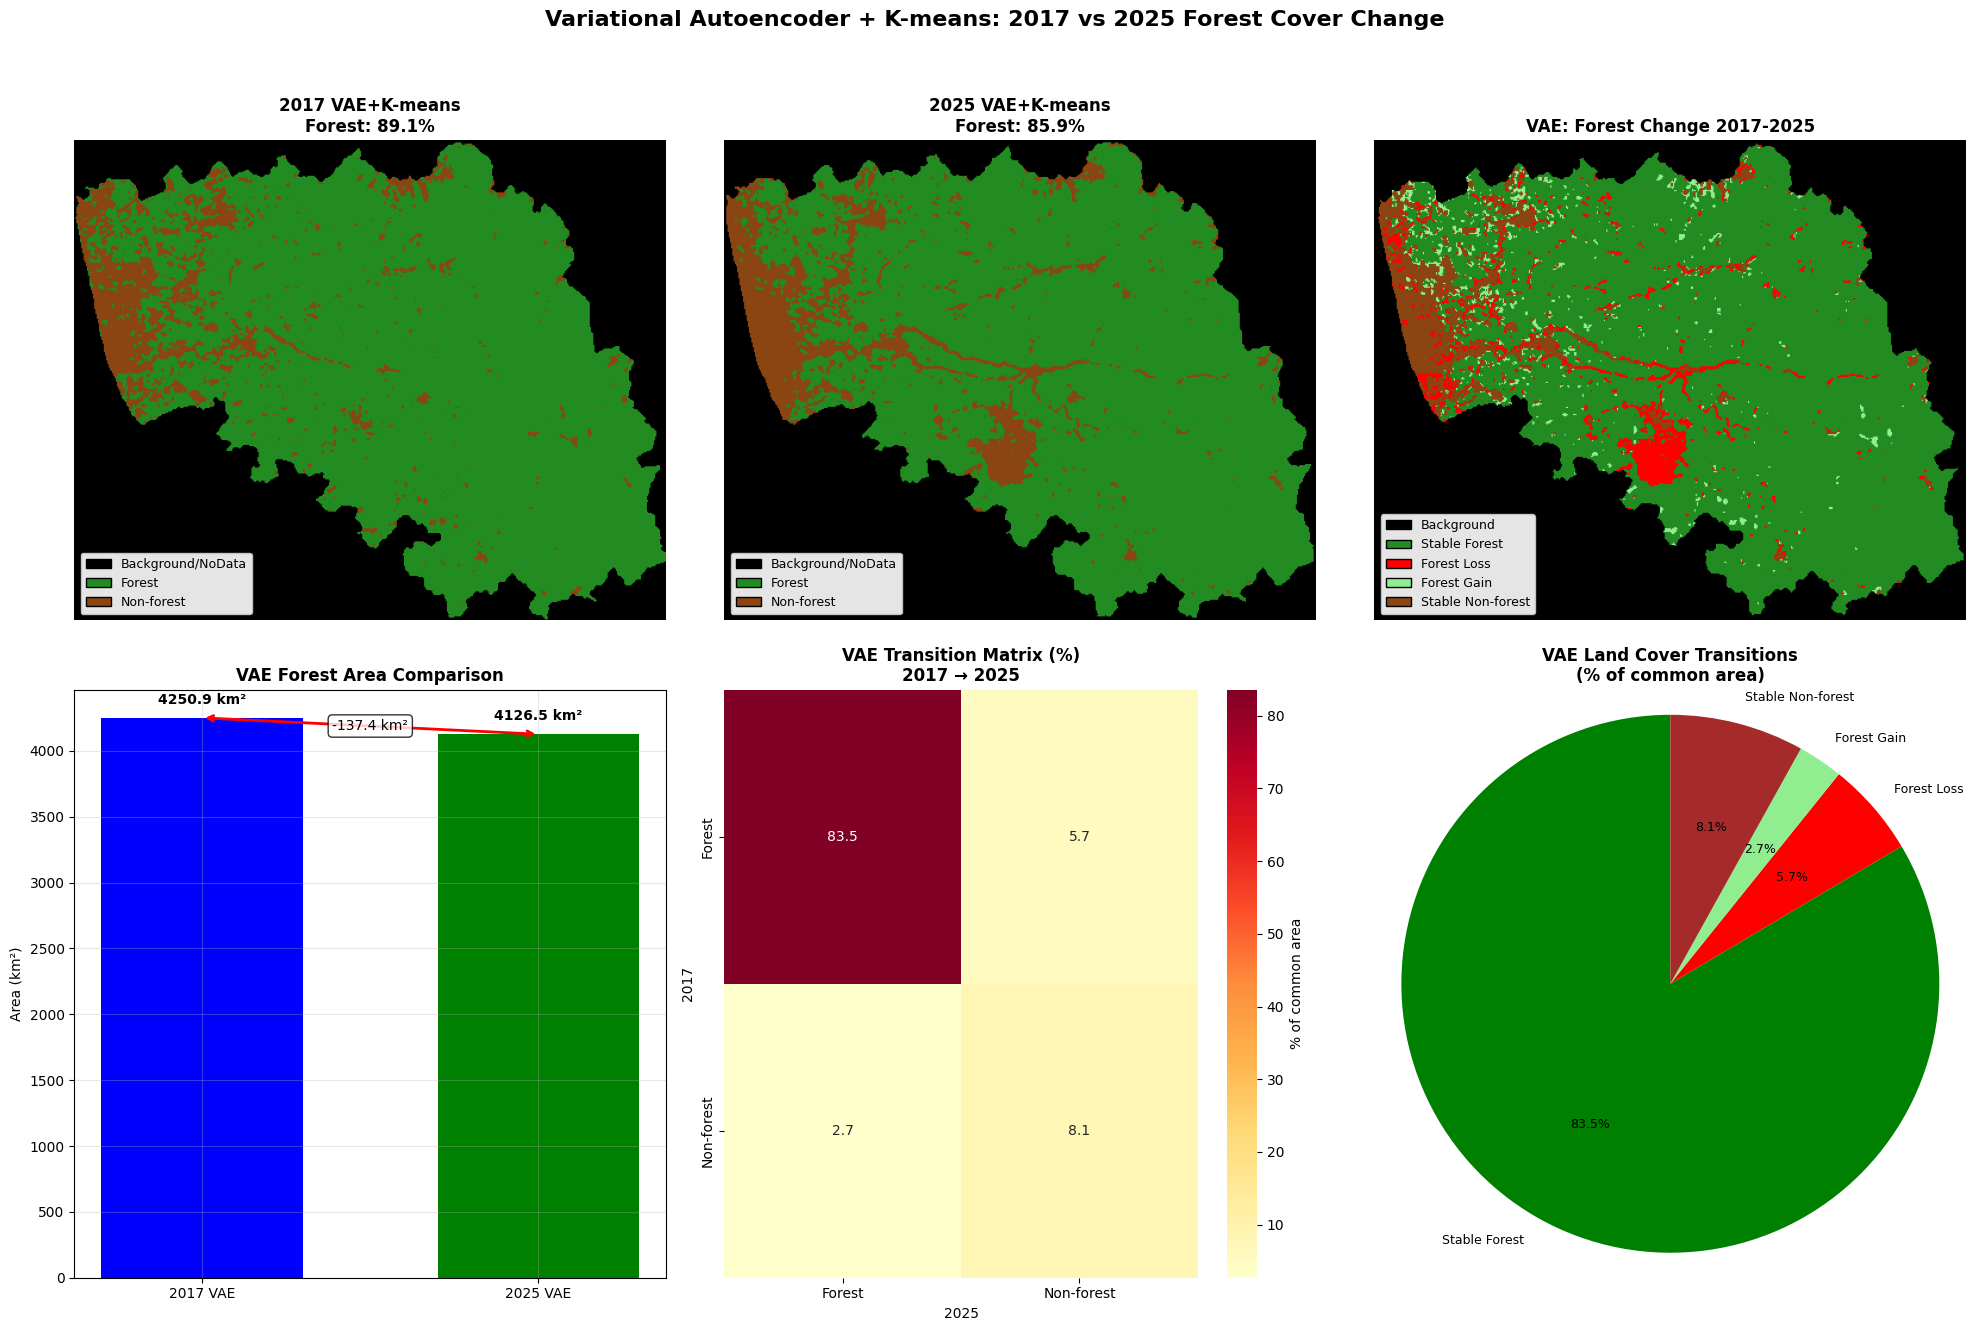

✓ VAE visualization saved: /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_2017_2025_VAE_Forest_Change_Comparison.png

💾 SAVING VAE COMPARISON RESULTS...
✓ VAE change map saved: /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_Forest_Change_2017_2025_VAE.tif


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


✓ VAE comparison statistics saved: /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_2017_2025_VAE_Comparison_Statistics.csv
✓ VAE report generated: /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_VAE_TimeSeries_Comparison_Report.txt

VARIATIONAL AUTOENCODER COMPARISON COMPLETE

📊 KEY FINDINGS:
  • 2017 Forest Cover (VAE): 89.1%
  • 2025 Forest Cover (VAE): 85.9%
  • Net Change (2017-2025): -3.0%
  • Annual Rate: -0.37% per year

📂 OUTPUT FILES:
  • /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_2017_2025_VAE_Forest_Change_Comparison.png
  • /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_Forest_Change_2017_2025_VAE.tif
  • /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_2017_2025_VAE_Comparison_Statistics.csv
  • /content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison/DK_VAE_TimeSeries_Comparison_Report.txt

VARIATIONAL AUTOENCODER ANALYSIS COMPLETE

📋 WHAT WAS ACCOMPLISHED:
1. ✅ 2017 VAE analysis completed
2. ✅ 2025 VAE results loaded
3

In [ ]:
# ====================================================
# VARIATIONAL AUTOENCODER + K-MEANS COMPARISON: 2017 vs 2025
# Standalone Comparison Notebook
# ====================================================

# ----------------- Install & imports -----------------
!pip install -q rasterio scikit-learn matplotlib pandas seaborn

import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib.patches import Patch
from scipy.ndimage import zoom
import pickle

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ====================================================
# SETUP PATHS
# ====================================================

# Define paths
OUTPUT_DIR_2017_VAE = "/content/drive/MyDrive/Dakshina_Kannada_2017_VAE"
OUTPUT_DIR_2025_VAE = "/content/drive/MyDrive/clippeddk/leora"  # Your 2025 VAE output
OUTPUT_COMPARISON_VAE = "/content/drive/MyDrive/Dakshina_Kannada_VAE_Comparison"

os.makedirs(OUTPUT_COMPARISON_VAE, exist_ok=True)

print("\n" + "="*70)
print("VARIATIONAL AUTOENCODER + K-MEANS COMPARISON: 2017 vs 2025")
print("Standalone Comparison Notebook")
print("="*70)

# ====================================================
# LOAD 2017 VAE RESULTS
# ====================================================

print("\n📊 LOADING 2017 VAE RESULTS...")

# Try to load from pickle file
results_2017_vae_file = os.path.join(OUTPUT_DIR_2017_VAE, "results_2017_vae.pkl")

if os.path.exists(results_2017_vae_file):
    with open(results_2017_vae_file, 'rb') as f:
        results_2017_vae = pickle.load(f)
    print("✓ Loaded 2017 VAE results from pickle file")

    # Extract data
    binary_2017_vae = results_2017_vae['binary_map']
    forest_percent_2017_vae = results_2017_vae['forest_percentage']
    forest_area_2017_vae = results_2017_vae['forest_area_km2']
    forest_pixels_2017_vae = results_2017_vae['forest_pixels']
    total_pixels_2017_vae = results_2017_vae['total_pixels']
    pixel_area_km2_2017 = results_2017_vae['pixel_area_km2']
    mask_2017_vae = results_2017_vae['display_mask']
    print(f"  2017 VAE Forest: {forest_percent_2017_vae:.1f}% ({forest_area_2017_vae:.2f} km²)")

elif os.path.exists(os.path.join(OUTPUT_DIR_2017_VAE, "DK_2017_VAE_Metrics.csv")):
    # Load from CSV and TIFF files if pickle doesn't exist
    print("✓ Loading 2017 VAE results from CSV and TIFF files")

    # Load metrics
    metrics_2017_vae_file = os.path.join(OUTPUT_DIR_2017_VAE, "DK_2017_VAE_Metrics.csv")
    metrics_2017_vae = pd.read_csv(metrics_2017_vae_file)

    forest_percent_2017_vae = metrics_2017_vae['Forest_Percentage'].iloc[0]
    forest_area_2017_vae = metrics_2017_vae['Forest_Area_km2'].iloc[0]
    forest_pixels_2017_vae = metrics_2017_vae['Forest_Pixels'].iloc[0]
    total_pixels_2017_vae = metrics_2017_vae['Total_Pixels'].iloc[0]
    pixel_area_km2_2017 = metrics_2017_vae['Pixel_Area_km2'].iloc[0]

    # Load classification map
    binary_2017_vae_file = os.path.join(OUTPUT_DIR_2017_VAE, "DK_LULC_2017_VAE_Kmeans.tif")
    with rasterio.open(binary_2017_vae_file) as src:
        binary_2017_vae = src.read(1)
        nodata_2017_vae = src.nodata

    # Create mask
    mask_2017_vae = binary_2017_vae > 0
    mask_2017_vae = mask_2017_vae & (binary_2017_vae != nodata_2017_vae)

    print(f"  2017 VAE Forest: {forest_percent_2017_vae:.1f}% ({forest_area_2017_vae:.2f} km²)")

else:
    print("❌ ERROR: No 2017 VAE results found!")
    print(f"   Check if directory exists: {OUTPUT_DIR_2017_VAE}")
    raise FileNotFoundError("2017 VAE results not found")

# ====================================================
# LOAD 2025 VAE RESULTS
# ====================================================

# ====================================================
# LOAD 2025 VAE RESULTS
# ====================================================

print("\n📊 LOADING 2025 VAE RESULTS...")

# Try to find 2025 VAE files
binary_2025_vae_files = [
    "LULC_VAE_Kmeans_DW_interior.tif",
    "LULC_VAE_Kmeans.tif",
    "DK_2025_VAE.tif"
]

binary_2025_vae = None
for vae_file in binary_2025_vae_files:
    vae_path = os.path.join(OUTPUT_DIR_2025_VAE, vae_file)
    if os.path.exists(vae_path):
        with rasterio.open(vae_path) as src:
            binary_2025_vae = src.read(1)
            nodata_2025_vae = src.nodata

            # FIX: Convert NoData (255) to 0 for proper visualization
            print(f"2025 VAE nodata value: {nodata_2025_vae}")
            if nodata_2025_vae is not None:
                # Create a copy and convert NoData values to 0
                binary_2025_vae_clean = binary_2025_vae.copy()
                binary_2025_vae_clean[binary_2025_vae == nodata_2025_vae] = 0
                binary_2025_vae = binary_2025_vae_clean
                print(f"Converted {np.sum(binary_2025_vae == 0)} pixels from {nodata_2025_vae} to 0")

            print(f"2025 VAE unique values after cleaning: {np.unique(binary_2025_vae)}")

        print(f"✓ Loaded 2025 VAE classification map from: {vae_file}")
        break

if binary_2025_vae is None:
    print("❌ ERROR: No 2025 VAE classification map found!")
    raise FileNotFoundError("2025 VAE classification map not found")

# Create mask for 2025 - after cleaning, background is 0
mask_2025_vae = binary_2025_vae > 0  # Valid pixels are > 0

# Calculate 2025 metrics
forest_pixels_2025_vae = np.sum(binary_2025_vae == 1)
total_pixels_2025_vae = np.sum(mask_2025_vae)
forest_percent_2025_vae = (forest_pixels_2025_vae / total_pixels_2025_vae * 100) if total_pixels_2025_vae > 0 else 0
forest_area_2025_vae = forest_pixels_2025_vae * pixel_area_km2_2017

print(f"  2025 VAE Forest: {forest_percent_2025_vae:.1f}% ({forest_area_2025_vae:.2f} km²)")

# ====================================================
# VAE COMPARISON ANALYSIS FUNCTION
# ====================================================

def compare_vae_2017_2025(binary_2017, binary_2025, mask_2017,
                         forest_percent_2017, forest_area_2017, forest_pixels_2017,
                         forest_percent_2025, forest_area_2025, forest_pixels_2025,
                         pixel_area_km2, output_dir):
    """Compare 2017 and 2025 Variational Autoencoder + K-means results"""

    print("\n📈 PERFORMING VAE COMPARISON ANALYSIS...")

    # Ensure same shape (resample if necessary)
    if binary_2017.shape != binary_2025.shape:
        print(f"⚠️ Shape mismatch: 2017={binary_2017.shape}, 2025={binary_2025.shape}")

        # Resample the smaller to match the larger
        if binary_2017.shape[0] * binary_2017.shape[1] > binary_2025.shape[0] * binary_2025.shape[1]:
            print("Resampling 2025 to match 2017...")
            scale_y = binary_2017.shape[0] / binary_2025.shape[0]
            scale_x = binary_2017.shape[1] / binary_2025.shape[1]
            binary_2025_resampled = zoom(binary_2025, (scale_y, scale_x), order=0)
            binary_2025_resampled = binary_2025_resampled[:binary_2017.shape[0], :binary_2017.shape[1]]
            binary_2025 = binary_2025_resampled
        else:
            print("Resampling 2017 to match 2025...")
            scale_y = binary_2025.shape[0] / binary_2017.shape[0]
            scale_x = binary_2025.shape[1] / binary_2017.shape[1]
            binary_2017_resampled = zoom(binary_2017, (scale_y, scale_x), order=0)
            binary_2017_resampled = binary_2017_resampled[:binary_2025.shape[0], :binary_2025.shape[1]]
            binary_2017 = binary_2017_resampled
            mask_2017 = zoom(mask_2017.astype(float), (scale_y, scale_x), order=0)
            mask_2017 = mask_2017[:binary_2025.shape[0], :binary_2025.shape[1]] > 0.5

    # Create masks for both years
    mask_2025 = binary_2025 > 0

    # Create common mask (valid in both years)
    common_mask = mask_2017 & mask_2025

    print(f"\n📊 PIXEL COUNTS:")
    print(f"  2017 valid pixels: {np.sum(mask_2017):,}")
    print(f"  2025 valid pixels: {np.sum(mask_2025):,}")
    print(f"  Common area pixels: {np.sum(common_mask):,}")

    # Calculate change matrix
    print("\n📊 CHANGE MATRIX (2017 → 2025):")

    # For common area only
    binary_2017_common = binary_2017.copy()
    binary_2025_common = binary_2025.copy()
    binary_2017_common[~common_mask] = 0
    binary_2025_common[~common_mask] = 0

    change_matrix = np.zeros((3, 3), dtype=int)  # 0=Background, 1=Forest, 2=Non-forest

    for i in range(3):
        for j in range(3):
            change_matrix[i, j] = np.sum((binary_2017_common == i) & (binary_2025_common == j))

    print("Rows: 2017, Columns: 2025")
    print("0=Background, 1=Forest, 2=Non-forest")
    print(change_matrix)

    # Extract change statistics
    stable_forest = change_matrix[1, 1]
    forest_loss = change_matrix[1, 2]    # Forest → Non-forest
    forest_gain = change_matrix[2, 1]    # Non-forest → Forest
    stable_nonforest = change_matrix[2, 2]

    total_common = np.sum(common_mask)

    if total_common > 0:
        forest_2017_common = stable_forest + forest_loss
        forest_2025_common = stable_forest + forest_gain

        forest_percent_2017_common = (forest_2017_common / total_common) * 100
        forest_percent_2025_common = (forest_2025_common / total_common) * 100

        forest_change_pixels = forest_2025_common - forest_2017_common
        forest_change_percent = forest_percent_2025_common - forest_percent_2017_common

        # Area calculations
        forest_area_2017_common = forest_2017_common * pixel_area_km2
        forest_area_2025_common = forest_2025_common * pixel_area_km2
        area_change_km2 = forest_area_2025_common - forest_area_2017_common

        print(f"\n🌳 FOREST CHANGE IN COMMON AREA (VAE):")
        print(f"  2017 Forest: {forest_2017_common:,} pixels ({forest_percent_2017_common:.1f}%)")
        print(f"  2025 Forest: {forest_2025_common:,} pixels ({forest_percent_2025_common:.1f}%)")
        print(f"  Change: {forest_change_pixels:+,} pixels ({forest_change_percent:+.1f}%)")
        print(f"\n  Area change: {area_change_km2:+.2f} km²")
        print(f"  (2017: {forest_area_2017_common:.2f} km² → 2025: {forest_area_2025_common:.2f} km²)")

        print(f"\n📊 CHANGE CATEGORIES:")
        print(f"  Stable forest: {stable_forest:,} pixels ({stable_forest/total_common*100:.1f}%)")
        print(f"  Forest loss: {forest_loss:,} pixels ({forest_loss/total_common*100:.1f}%)")
        print(f"  Forest gain: {forest_gain:,} pixels ({forest_gain/total_common*100:.1f}%)")
        print(f"  Stable non-forest: {stable_nonforest:,} pixels ({stable_nonforest/total_common*100:.1f}%)")

        # Annual change rate
        years_between = 2025 - 2017
        annual_change_rate = forest_change_percent / years_between
        print(f"\n📅 ANNUAL CHANGE RATE (2017-2025):")
        print(f"  {annual_change_rate:+.2f}% per year")
    else:
        print("⚠️ No common area for comparison!")
        return None

    # Create change map
    print("\n🗺️ CREATING VAE CHANGE MAP...")

    change_map = np.zeros_like(binary_2017, dtype=np.uint8)

    change_map[(binary_2017 == 1) & (binary_2025 == 1) & common_mask] = 1  # Stable forest
    change_map[(binary_2017 == 1) & (binary_2025 == 2) & common_mask] = 2  # Forest loss
    change_map[(binary_2017 == 2) & (binary_2025 == 1) & common_mask] = 3  # Forest gain
    change_map[(binary_2017 == 2) & (binary_2025 == 2) & common_mask] = 4  # Stable non-forest

        # ====================================================
    # VISUALIZATION
    # ====================================================
    print("\n🎨 CREATING VAE COMPARISON VISUALIZATIONS...")

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('Variational Autoencoder + K-means: 2017 vs 2025 Forest Cover Change',
                 fontsize=16, fontweight='bold', y=1.02)

    # 1. 2017 VAE Classification with legend (bottom left corner)
    cmap_class = ListedColormap(['#000000', '#228B22', '#8B4513'])
    im1 = axes[0,0].imshow(binary_2017, cmap=cmap_class, vmin=0, vmax=2)
    axes[0,0].set_title(f'2017 VAE+K-means\nForest: {forest_percent_2017:.1f}%', fontweight='bold')
    axes[0,0].axis('off')

    # Add legend for 2017 VAE classification (bottom left corner)
    legend_elements_2017 = [
        Patch(facecolor='#000000', edgecolor='black', label='Background/NoData'),
        Patch(facecolor='#228B22', edgecolor='black', label='Forest'),
        Patch(facecolor='#8B4513', edgecolor='black', label='Non-forest')
    ]
    axes[0,0].legend(handles=legend_elements_2017, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 2. 2025 VAE Classification with legend (bottom left corner)
    im2 = axes[0,1].imshow(binary_2025, cmap=cmap_class, vmin=0, vmax=2)
    axes[0,1].set_title(f'2025 VAE+K-means\nForest: {forest_percent_2025:.1f}%', fontweight='bold')
    axes[0,1].axis('off')

    # Add legend for 2025 VAE classification (bottom left corner)
    axes[0,1].legend(handles=legend_elements_2017, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 3. Change Map with legend (bottom left corner)
    change_cmap = ListedColormap(['#000000', '#228B22', '#FF0000', '#90EE90', '#8B4513'])
    im3 = axes[0,2].imshow(change_map, cmap=change_cmap, vmin=0, vmax=4)
    axes[0,2].set_title('VAE: Forest Change 2017-2025', fontweight='bold')
    axes[0,2].axis('off')

    # Add legend for change map (bottom left corner)
    legend_elements_change = [
        Patch(facecolor='#000000', edgecolor='black', label='Background'),
        Patch(facecolor='#228B22', edgecolor='black', label='Stable Forest'),
        Patch(facecolor='#FF0000', edgecolor='black', label='Forest Loss'),
        Patch(facecolor='#90EE90', edgecolor='black', label='Forest Gain'),
        Patch(facecolor='#8B4513', edgecolor='black', label='Stable Non-forest')
    ]
    axes[0,2].legend(handles=legend_elements_change, loc='lower left',
                     fontsize=9, framealpha=0.9)

    # 4. Forest Area Comparison Bar Chart
    years = ['2017 VAE', '2025 VAE']
    forest_areas = [forest_area_2017, forest_area_2025]

    bars = axes[1,0].bar(years, forest_areas, color=['blue', 'green'], width=0.6)
    axes[1,0].set_title('VAE Forest Area Comparison', fontweight='bold')
    axes[1,0].set_ylabel('Area (km²)')
    axes[1,0].grid(True, alpha=0.3)

    # Add value labels
    for bar, area in zip(bars, forest_areas):
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + max(forest_areas)*0.02,
                      f'{area:.1f} km²', ha='center', va='bottom', fontweight='bold')

    # Add change arrow
    change_text = f"{area_change_km2:+.1f} km²"
    arrow_color = 'green' if area_change_km2 >= 0 else 'red'
    axes[1,0].annotate('', xy=(1, forest_area_2025), xytext=(0, forest_area_2017),
                      arrowprops=dict(arrowstyle='<->', color=arrow_color, lw=2))
    axes[1,0].text(0.5, (forest_area_2017 + forest_area_2025)/2,
                  change_text, ha='center', va='center',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # 5. Transition Matrix Heatmap
    change_matrix_norm = change_matrix[1:, 1:] / np.sum(change_matrix[1:, 1:]) * 100

    sns.heatmap(change_matrix_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=['Forest', 'Non-forest'],
                yticklabels=['Forest', 'Non-forest'],
                cbar_kws={'label': '% of common area'},
                ax=axes[1,1])
    axes[1,1].set_title('VAE Transition Matrix (%)\n2017 → 2025', fontweight='bold')
    axes[1,1].set_xlabel('2025')
    axes[1,1].set_ylabel('2017')

    # 6. Change Composition Pie Chart
    labels = ['Stable Forest', 'Forest Loss', 'Forest Gain', 'Stable Non-forest']
    sizes = [stable_forest, forest_loss, forest_gain, stable_nonforest]
    colors = ['green', 'red', 'lightgreen', 'brown']

    # Filter out zero categories
    non_zero_indices = [i for i, size in enumerate(sizes) if size > 0]
    if non_zero_indices:
        labels_filtered = [labels[i] for i in non_zero_indices]
        sizes_filtered = [sizes[i] for i in non_zero_indices]
        colors_filtered = [colors[i] for i in non_zero_indices]

        axes[1,2].pie(sizes_filtered, labels=labels_filtered, colors=colors_filtered,
                     autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
        axes[1,2].axis('equal')
        axes[1,2].set_title('VAE Land Cover Transitions\n(% of common area)', fontweight='bold')
    else:
        axes[1,2].text(0.5, 0.5, 'No transitions\nin common area',
                      ha='center', va='center', transform=axes[1,2].transAxes)
        axes[1,2].axis('off')

    plt.tight_layout()

    # Save visualization
    vis_path = os.path.join(output_dir, "DK_2017_2025_VAE_Forest_Change_Comparison.png")
    plt.savefig(vis_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ VAE visualization saved: {vis_path}")

    # ====================================================
    # SAVE VAE COMPARISON RESULTS
    # ====================================================
    print("\n💾 SAVING VAE COMPARISON RESULTS...")

    # Save change map
    change_map_file = os.path.join(output_dir, "DK_Forest_Change_2017_2025_VAE.tif")

    # Create basic metadata
    meta = {
        "driver": "GTiff",
        "height": change_map.shape[0],
        "width": change_map.shape[1],
        "count": 1,
        "dtype": "uint8",
        "nodata": 0,
        "compress": "LZW"
    }

    with rasterio.open(change_map_file, "w", **meta) as dst:
        dst.write(change_map, 1)
        # Add colormap
        try:
            dst.write_colormap(1, {
                0: (0, 0, 0),       # Black - Background
                1: (34, 139, 34),   # Green - Stable forest
                2: (255, 0, 0),     # Red - Forest loss
                3: (144, 238, 144), # Light green - Forest gain
                4: (139, 69, 19)    # Brown - Stable non-forest
            })
        except:
            pass

    print(f"✓ VAE change map saved: {change_map_file}")

    # Save comparison statistics
    comparison_stats = {
        'Year': ['2017', '2025', 'Change'],
        'Model': ['Variational Autoencoder + K-means', 'Variational Autoencoder + K-means', 'N/A'],
        'Forest_Pixels_Total': [
            forest_pixels_2017,
            forest_pixels_2025,
            forest_pixels_2025 - forest_pixels_2017
        ],
        'Forest_Percentage_Total': [
            forest_percent_2017,
            forest_percent_2025,
            forest_percent_2025 - forest_percent_2017
        ],
        'Forest_Area_km2_Total': [
            forest_area_2017,
            forest_area_2025,
            forest_area_2025 - forest_area_2017
        ],
        'Common_Area_Pixels': [total_common, total_common, 0],
        'Forest_Pixels_Common': [forest_2017_common, forest_2025_common, forest_change_pixels],
        'Forest_Percentage_Common': [forest_percent_2017_common, forest_percent_2025_common, forest_change_percent],
        'Forest_Area_km2_Common': [forest_area_2017_common, forest_area_2025_common, area_change_km2],
        'Stable_Forest_Pixels': [stable_forest, stable_forest, 0],
        'Forest_Loss_Pixels': [forest_loss, forest_loss, 0],
        'Forest_Gain_Pixels': [forest_gain, forest_gain, 0],
        'Stable_NonForest_Pixels': [stable_nonforest, stable_nonforest, 0],
        'Pixel_Area_km2': [pixel_area_km2, pixel_area_km2, 0],
        'Annual_Change_Rate_%': [None, None, annual_change_rate]
    }

    comparison_df = pd.DataFrame(comparison_stats)
    stats_path = os.path.join(output_dir, "DK_2017_2025_VAE_Comparison_Statistics.csv")
    comparison_df.to_csv(stats_path, index=False)
    print(f"✓ VAE comparison statistics saved: {stats_path}")

    # Generate VAE comparison report
    report_path = os.path.join(output_dir, "DK_VAE_TimeSeries_Comparison_Report.txt")
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("DAKSHINA KANNADA VARIATIONAL AUTOENCODER ANALYSIS REPORT\n")
        f.write("2017 vs 2025 Time Series Comparison\n")
        f.write("="*80 + "\n\n")

        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*40 + "\n")
        f.write(f"2017 Forest cover (VAE): {forest_percent_2017:.1f}%\n")
        f.write(f"2025 Forest cover (VAE): {forest_percent_2025:.1f}%\n")
        f.write(f"Net change (2017-2025): {forest_change_percent:+.1f}%\n")
        f.write(f"Annual change rate: {annual_change_rate:+.2f}% per year\n\n")

        f.write(f"2017 Forest area: {forest_area_2017:.2f} km²\n")
        f.write(f"2025 Forest area: {forest_area_2025:.2f} km²\n")
        f.write(f"Area change: {area_change_km2:+.2f} km²\n\n")

        f.write("CHANGE CATEGORIES (Common Area)\n")
        f.write("-"*40 + "\n")
        f.write(f"Stable forest: {stable_forest:,} pixels ({stable_forest/total_common*100:.1f}%)\n")
        f.write(f"Forest loss: {forest_loss:,} pixels ({forest_loss/total_common*100:.1f}%)\n")
        f.write(f"Forest gain: {forest_gain:,} pixels ({forest_gain/total_common*100:.1f}%)\n")
        f.write(f"Stable non-forest: {stable_nonforest:,} pixels ({stable_nonforest/total_common*100:.1f}%)\n\n")

        f.write("METHODOLOGY - Variational Autoencoder + K-means\n")
        f.write("-"*40 + "\n")
        f.write("2017 Data:\n")
        f.write("  • Source: Sentinel-2 TOA (Top of Atmosphere)\n")
        f.write("  • Period: January-February 2017\n")
        f.write("  • Processing: Variational Autoencoder + K-means\n")
        f.write("  • VAE Architecture: Encoder + Latent Space + Decoder\n")
        f.write("  • Loss: Reconstruction + KL Divergence\n")
        f.write("  • Classification: Multi-threshold (NDVI, MNDWI, NDBI)\n")
        f.write("\n2025 Data:\n")
        f.write("  • Source: Sentinel-2 SR (Surface Reflectance)\n")
        f.write("  • Period: January-February 2025\n")
        f.write("  • Processing: Variational Autoencoder + K-means\n")
        f.write("  • Validation: Dynamic World reference data\n")
        f.write("\nComparison:\n")
        f.write("  • Pixel-by-pixel analysis in common area\n")
        f.write("  • Change matrix calculation\n")
        f.write("  • Area calculation using geographic projection\n")
        f.write(f"  • Pixel area: {pixel_area_km2:.6f} km²\n\n")

        f.write("DATA QUALITY NOTES\n")
        f.write("-"*40 + "\n")
        f.write("1. 2017 data is TOA, 2025 data is SR - reflectance differences exist\n")
        f.write("2. Different atmospheric correction methods\n")
        f.write("3. Same VAE architecture and classification thresholds applied to both years\n")
        f.write("4. Common area analysis ensures fair comparison\n")
        f.write("5. Annual rate calculated over 8-year period (2017-2025)\n\n")

        f.write("VAE ADVANTAGES\n")
        f.write("-"*40 + "\n")
        f.write("1. Probabilistic latent space representation\n")
        f.write("2. Regularization via KL divergence prevents overfitting\n")
        f.write("3. Better handling of uncertainty in predictions\n")
        f.write("4. Smooth interpolation capabilities in latent space\n")
        f.write("5. More robust to outliers compared to standard autoencoder\n")
        f.write("6. Multi-threshold classification for better discrimination\n")

    print(f"✓ VAE report generated: {report_path}")

    # Summary
    print("\n" + "="*70)
    print("VARIATIONAL AUTOENCODER COMPARISON COMPLETE")
    print("="*70)
    print(f"\n📊 KEY FINDINGS:")
    print(f"  • 2017 Forest Cover (VAE): {forest_percent_2017:.1f}%")
    print(f"  • 2025 Forest Cover (VAE): {forest_percent_2025:.1f}%")
    print(f"  • Net Change (2017-2025): {forest_change_percent:+.1f}%")
    print(f"  • Annual Rate: {annual_change_rate:+.2f}% per year")

    print(f"\n📂 OUTPUT FILES:")
    print(f"  • {vis_path}")
    print(f"  • {change_map_file}")
    print(f"  • {stats_path}")
    print(f"  • {report_path}")

    return {
        'change_map': change_map,
        'comparison_df': comparison_df,
        'change_matrix': change_matrix,
        'forest_change_percent': forest_change_percent,
        'annual_change_rate': annual_change_rate
    }

# ====================================================
# RUN THE VAE COMPARISON
# ====================================================

print("\n" + "="*70)
print("STARTING VARIATIONAL AUTOENCODER COMPARISON")
print("="*70)

# Run VAE comparison
vae_comparison_results = compare_vae_2017_2025(
    binary_2017=binary_2017_vae,
    binary_2025=binary_2025_vae,
    mask_2017=mask_2017_vae,
    forest_percent_2017=forest_percent_2017_vae,
    forest_area_2017=forest_area_2017_vae,
    forest_pixels_2017=forest_pixels_2017_vae,
    forest_percent_2025=forest_percent_2025_vae,
    forest_area_2025=forest_area_2025_vae,
    forest_pixels_2025=forest_pixels_2025_vae,
    pixel_area_km2=pixel_area_km2_2017,
    output_dir=OUTPUT_COMPARISON_VAE
)

# ====================================================
# FINAL SUMMARY
# ====================================================

print("\n" + "="*70)
print("VARIATIONAL AUTOENCODER ANALYSIS COMPLETE")
print("="*70)

print("\n📋 WHAT WAS ACCOMPLISHED:")
print("1. ✅ 2017 VAE analysis completed")
print("2. ✅ 2025 VAE results loaded")
print("3. ✅ Comprehensive VAE comparison analysis")
print("4. ✅ Change detection and transition matrix")
print("5. ✅ Area calculations and annual change rates")

print(f"\n📂 OUTPUT DIRECTORIES:")
print(f"   2017 VAE Results: {OUTPUT_DIR_2017_VAE}")
print(f"   2025 VAE Results: {OUTPUT_DIR_2025_VAE}")
print(f"   VAE Comparison Results: {OUTPUT_COMPARISON_VAE}")

print("\n⚠️  IMPORTANT NOTES:")
print("   1. 2017: Sentinel-2 TOA (Top of Atmosphere)")
print("   2. 2025: Sentinel-2 SR (Surface Reflectance)")
print("   3. Different atmospheric correction methods")
print("   4. Same VAE architecture and multi-threshold classification used")
print("   5. Results show VAE-specific change patterns")

print("\n🎉 VARIATIONAL AUTOENCODER ANALYSIS COMPLETED!")
print("   You now have comparable VAE forest cover maps for 2017 and 2025")

# ====================================================
# OPTIONAL: SAVE VAE COMPARISON RESULTS
# ====================================================

if vae_comparison_results:
    # Save comparison results
    vae_comparison_file = os.path.join(OUTPUT_COMPARISON_VAE, "vae_comparison_results.pkl")
    with open(vae_comparison_file, 'wb') as f:
        pickle.dump(vae_comparison_results, f)
    print(f"\n✓ VAE comparison results saved: {vae_comparison_file}")